In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

train_path_features = r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\training_set_features.csv'
train_path_labels  = r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\training_set_labels.csv'

test_path_features = r'C:\Users\divye\Data_science_projects\H1N1_seasonal_vaccines\data\test_set_features.csv'


train_df_features = pd.read_csv(train_path_features)
train_df_labels = pd.read_csv(train_path_labels)

merged_df = pd.merge(train_df_features, train_df_labels, on='respondent_id', how='inner')

print(merged_df.shape)
print(merged_df.head())

(26707, 38)
   respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0              0           1.0             0.0                        0.0   
1              1           3.0             2.0                        0.0   
2              2           1.0             1.0                        0.0   
3              3           1.0             1.0                        0.0   
4              4           2.0             1.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   0.0                   0.0                    0.0   
1                   1.0                   0.0                    1.0   
2                   1.0                   0.0                    0.0   
3                   1.0                   0.0                    1.0   
4                   1.0                   0.0                    1.0   

   behavioral_large_gatherings  behavioral_outside_home  \
0                          0.0   

In [4]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

In [5]:
merged_df.isna().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

# EDA

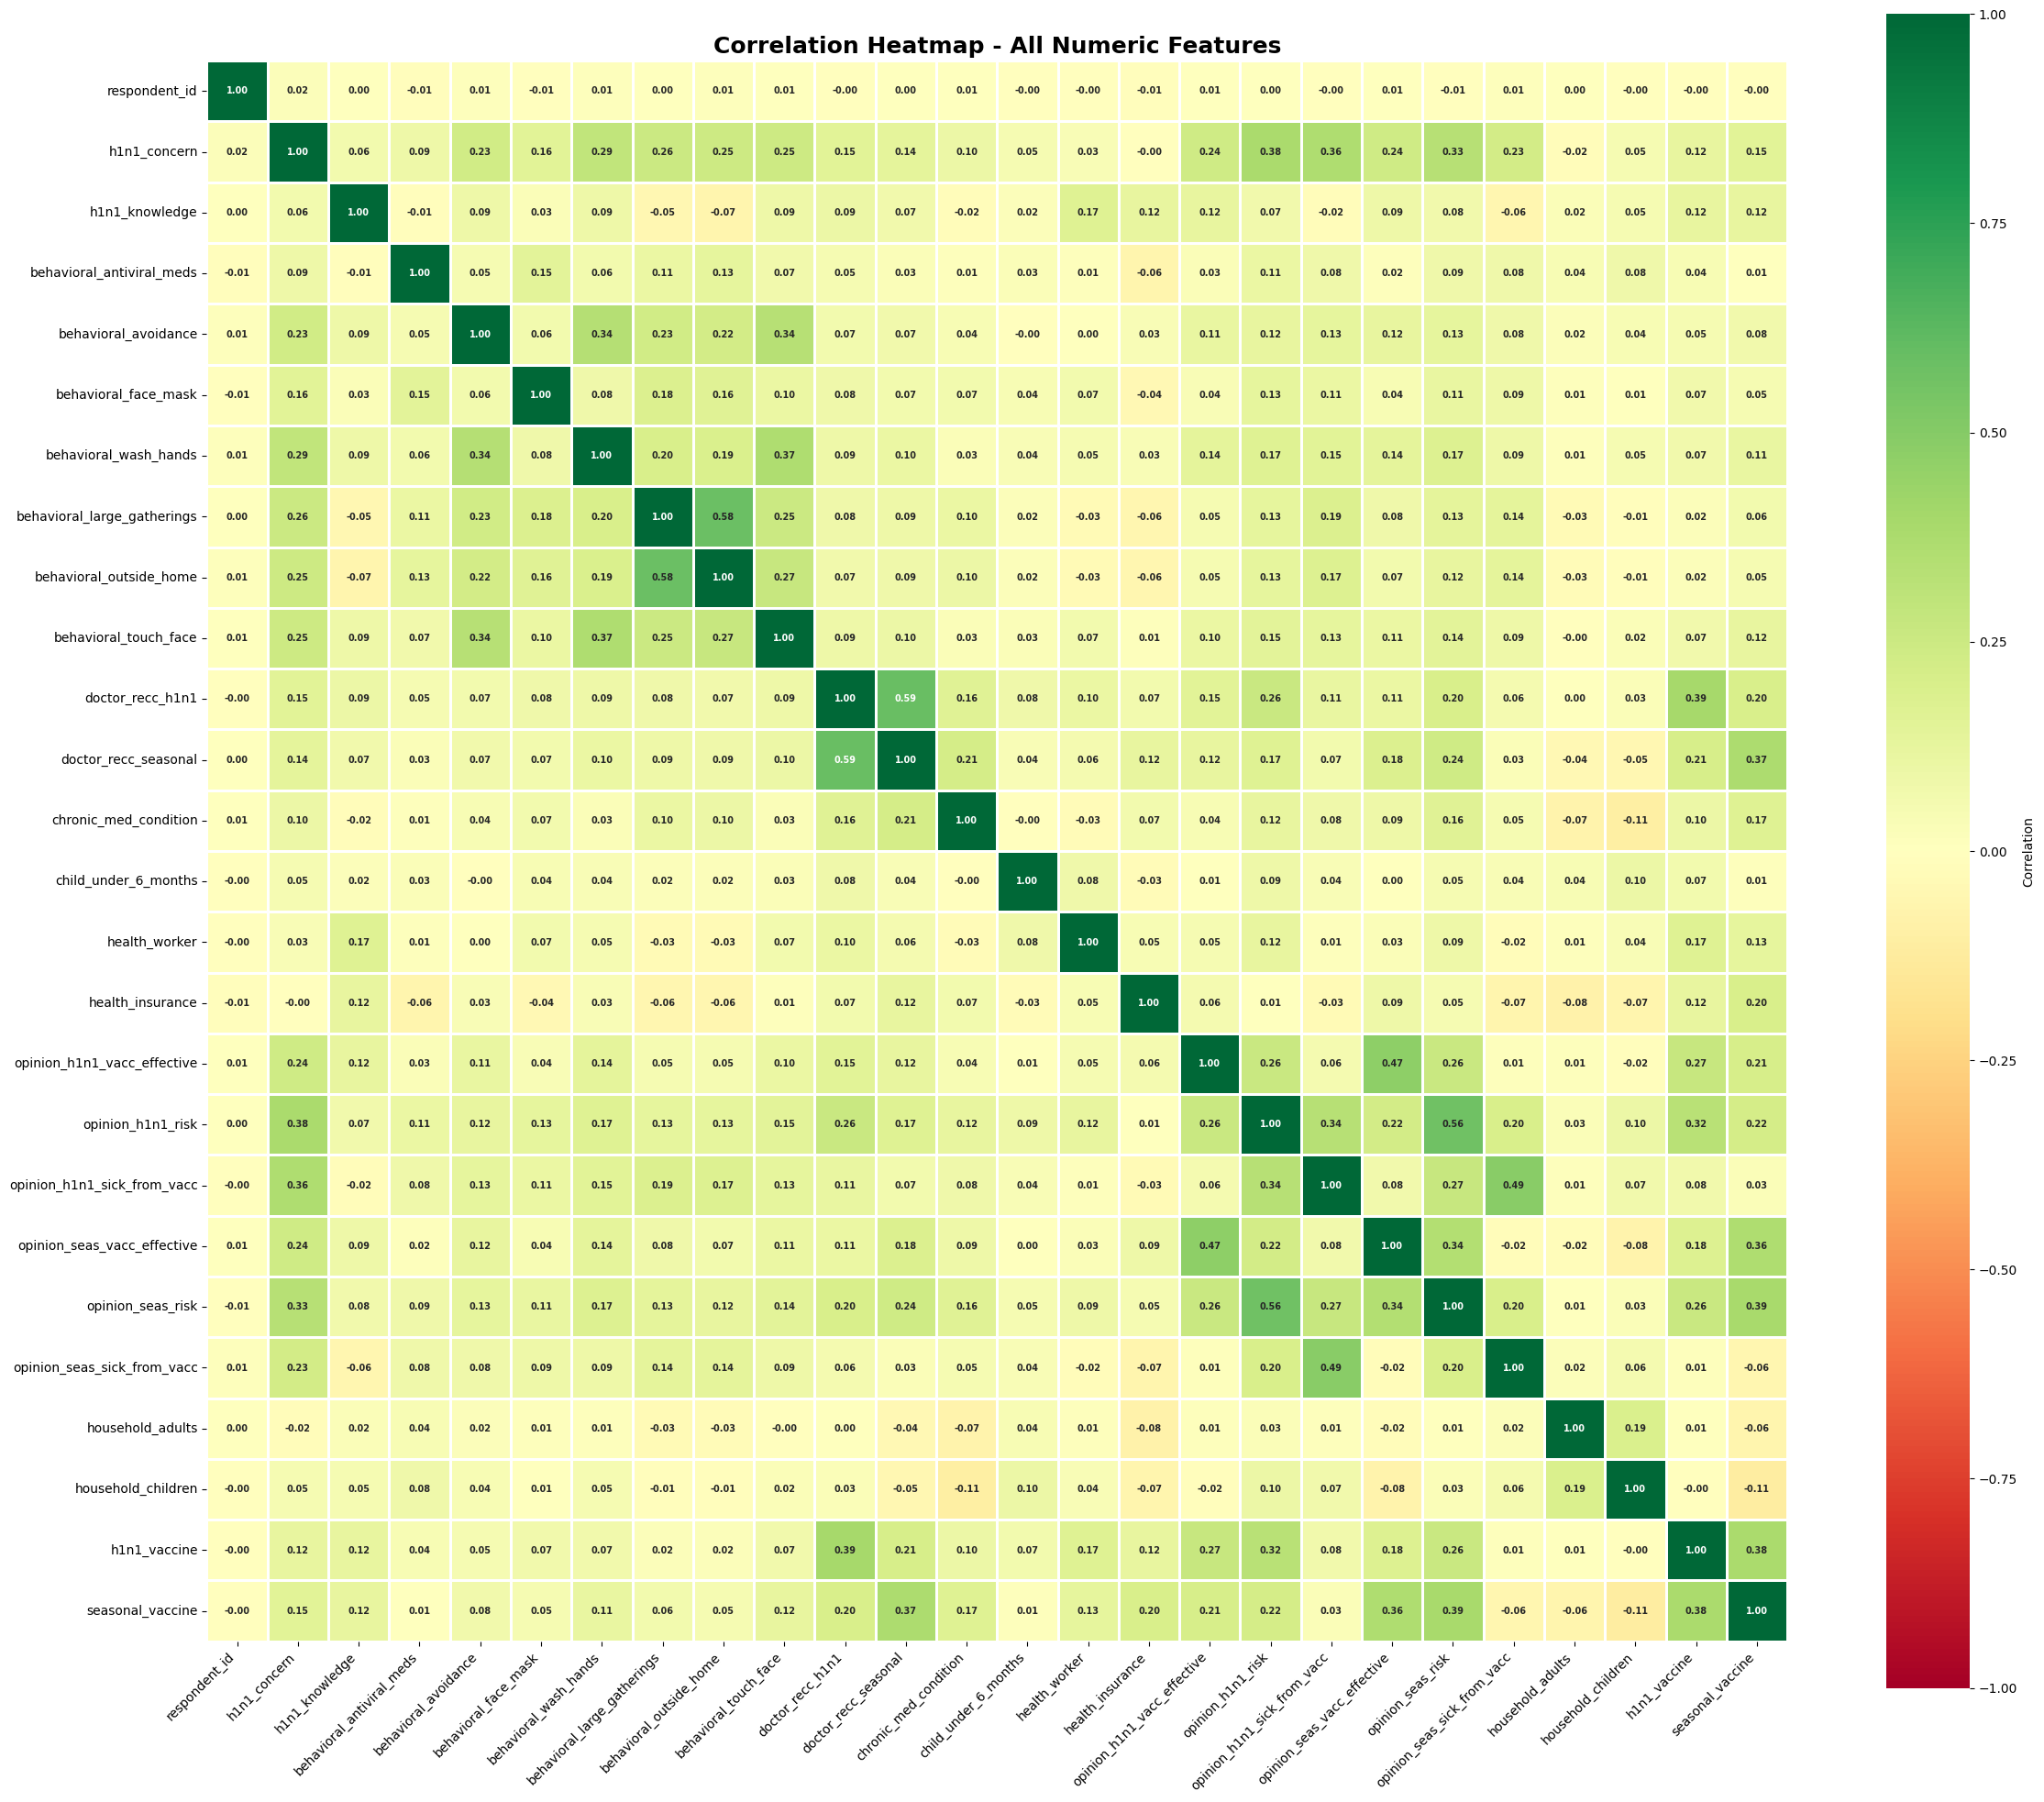

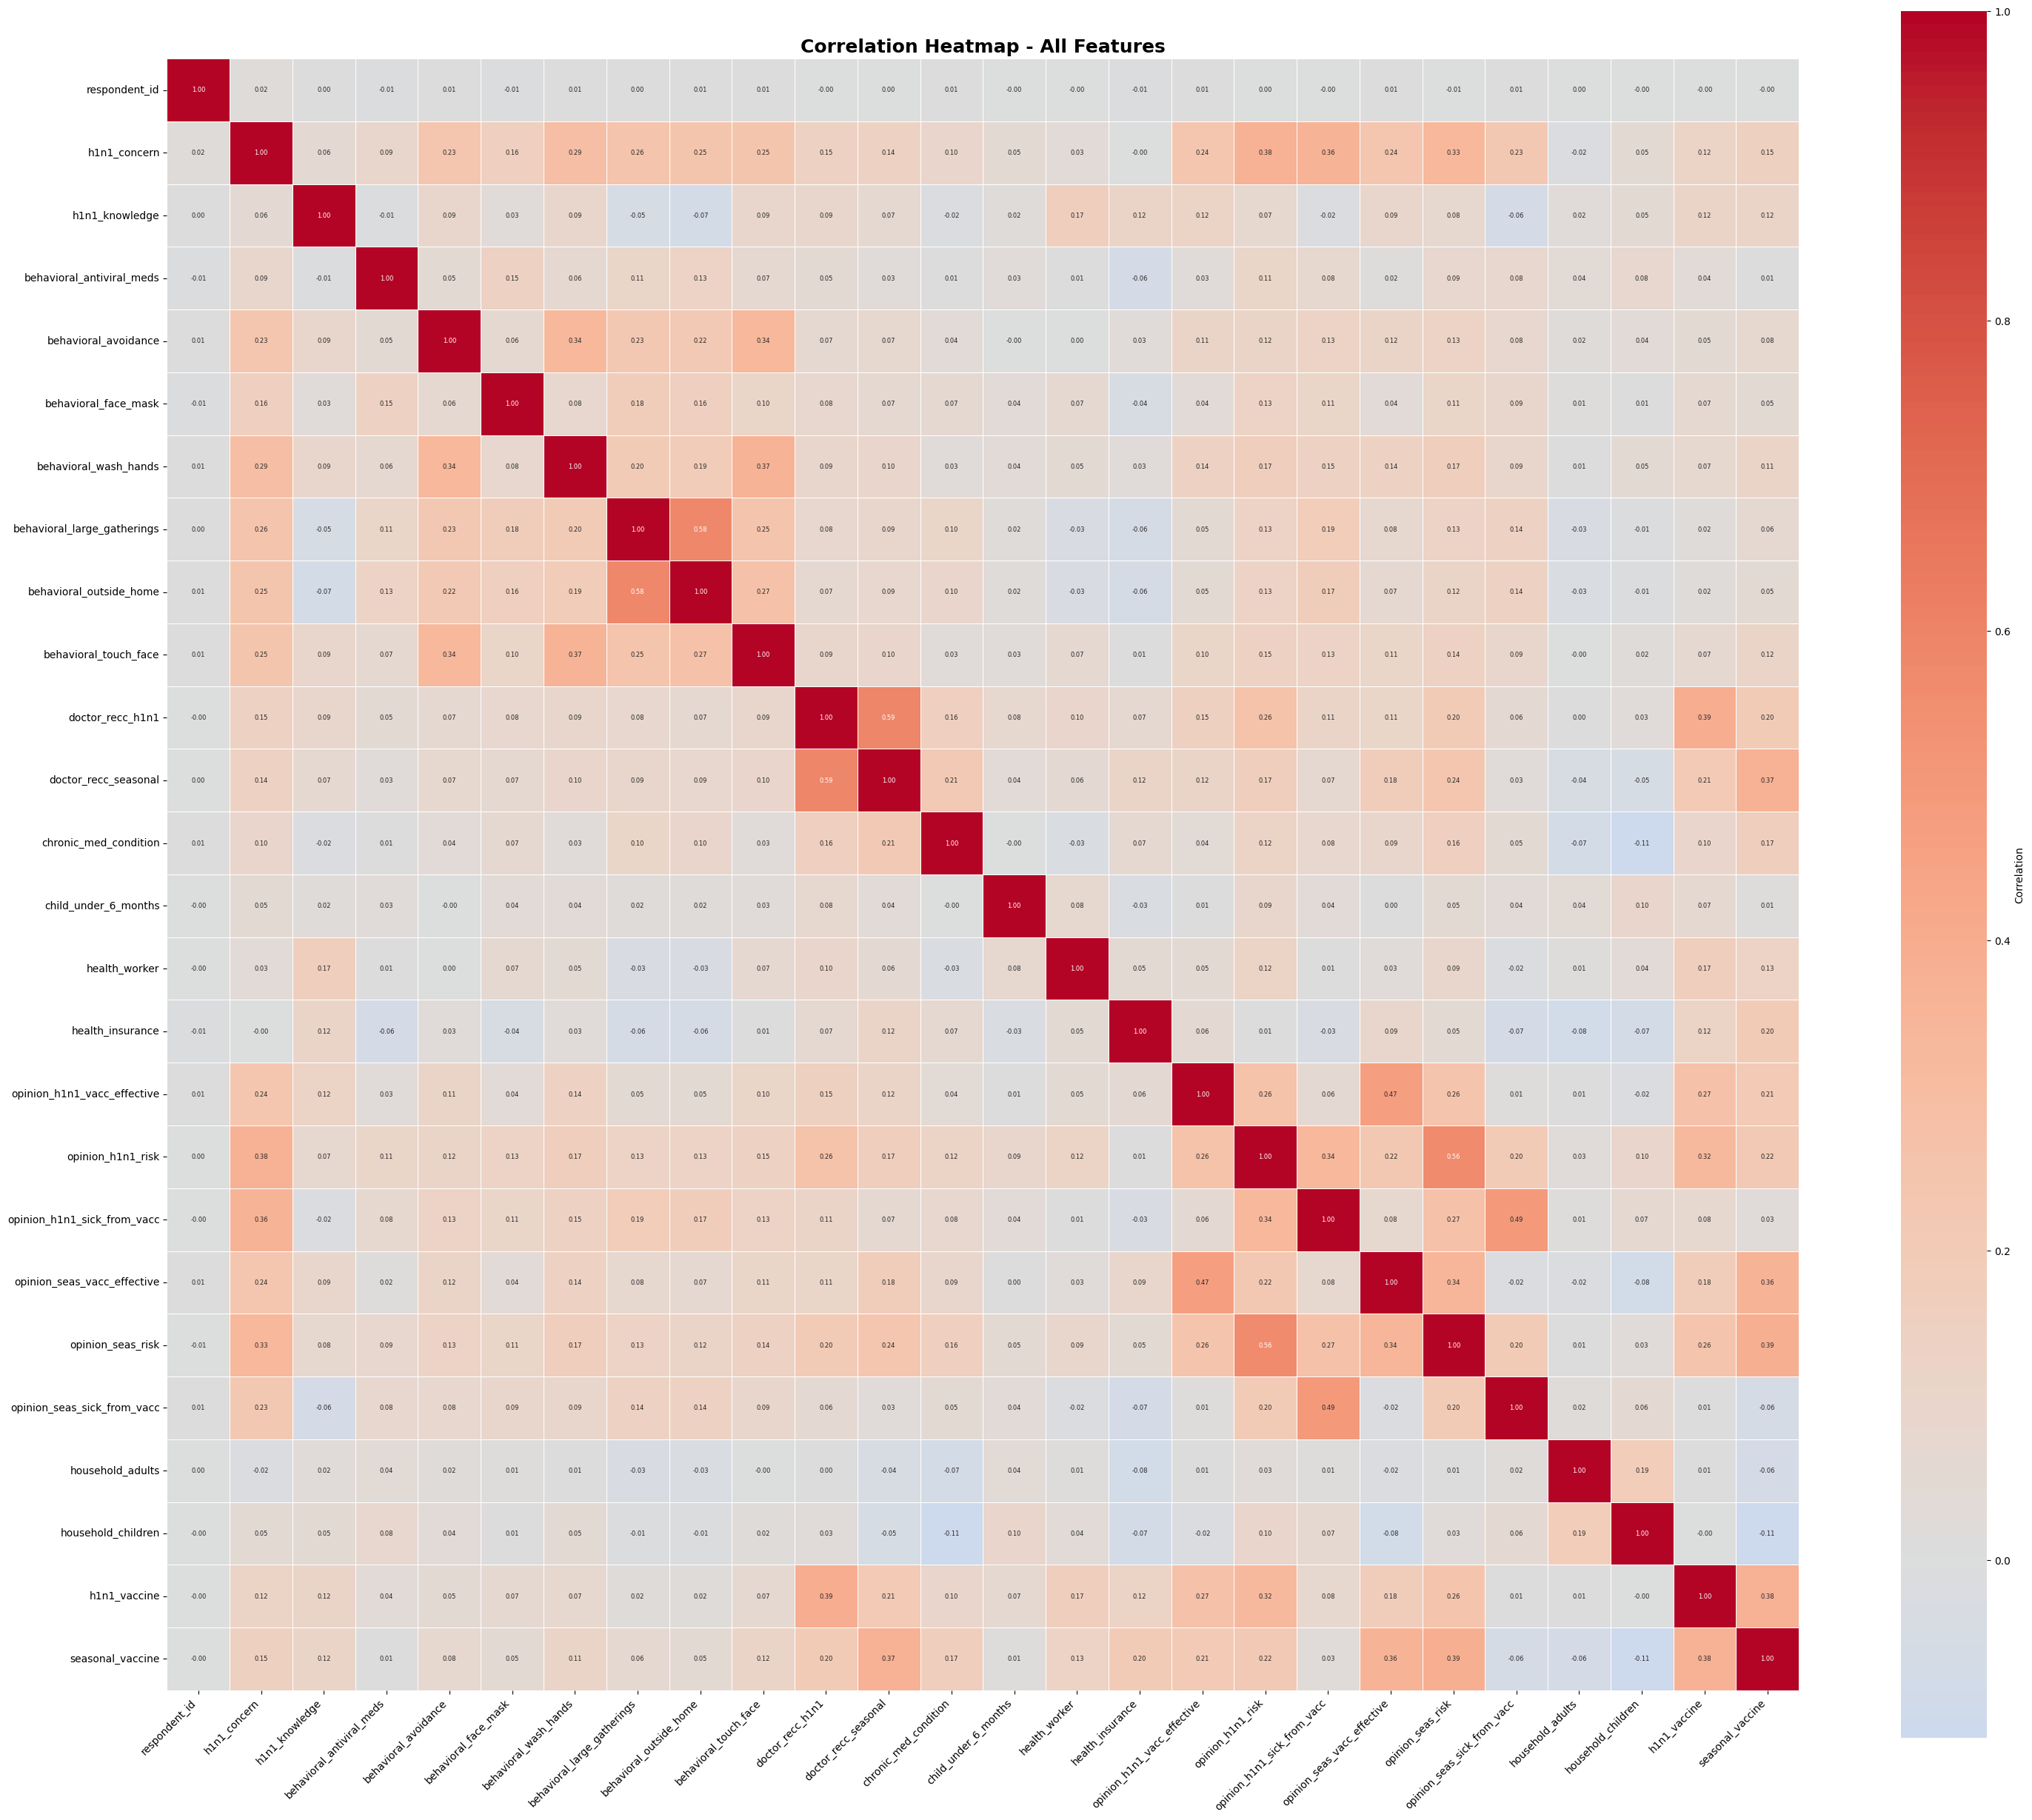

Correlation Matrix Shape: (26, 26)

Correlation Matrix:
                             respondent_id  h1n1_concern  h1n1_knowledge  \
respondent_id                     1.000000      0.017839        0.003425   
h1n1_concern                      0.017839      1.000000        0.062522   
h1n1_knowledge                    0.003425      0.062522        1.000000   
behavioral_antiviral_meds        -0.008475      0.090301       -0.010836   
behavioral_avoidance              0.009638      0.233713        0.088839   
behavioral_face_mask             -0.006644      0.156032        0.030050   
behavioral_wash_hands             0.011105      0.293565        0.089785   
behavioral_large_gatherings       0.004539      0.255031       -0.048898   
behavioral_outside_home           0.009011      0.246424       -0.068219   
behavioral_touch_face             0.007575      0.248016        0.086162   
doctor_recc_h1n1                 -0.002072      0.150206        0.093829   
doctor_recc_seasonal            

In [7]:


# Get all numeric columns
numeric_df = merged_df.select_dtypes(include=['number'])

# Create correlation matrix for all features
corr_matrix = numeric_df.corr()

# Method 1: Larger Figure with Better Readability
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, cbar_kws={'label': 'Correlation'}, 
            linewidths=1, square=True, 
            annot_kws={'size': 7, 'weight': 'bold'}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap - All Numeric Features', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Method 2: Save as Image (If too large to display)
plt.figure(figsize=(30, 25))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Correlation'}, 
            linewidths=0.5, square=True, annot_kws={'size': 6})
plt.title('Correlation Heatmap - All Features', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# Method 5: Print correlation statistics
print("Correlation Matrix Shape:", corr_matrix.shape)
print("\nCorrelation Matrix:")
print(corr_matrix)

Key Observations:
1. Strong Positive Correlations (Red - 0.6+):

doctor_recc_h1n1 ↔ doctor_recc_seasonal (0.63) - Very strong, makes sense as vaccination recommendations often go together
opinion_h1n1_risk ↔ opinion_seas_risk (0.56) - People's risk perception is consistent across both vaccines
opinion_h1n1_sick_from_vacc ↔ opinion_seas_sick_from_vacc (0.49) - Similar concerns about side effects
opinion_h1n1_vacc_effective ↔ seasonal_vaccine (0.36-0.39) - Effectiveness opinions correlate
h1n1_concern ↔ behavioral_avoidance (0.34) - Higher concern leads to avoidance behavior
opinion_seas_risk ↔ seasonal_vaccine (0.39) - Risk perception drives vaccine uptake

2. Moderate Correlations (Orange - 0.2-0.6):

Behavioral measures (wash_hands, avoid gatherings, wear mask) show 0.2-0.34 correlation with each other
Opinion variables tend to correlate moderately with behavioral actions
h1n1_concern shows consistent 0.23-0.33 correlations with various behavioral measures

3. Weak/No Correlations (Light/Blue - 0-0.2):

respondent_id has almost no correlation with anything (0.00s) - good, no data leakage
Demographics (household_adults, household_children) show minimal correlation with opinions/behaviors
Health worker status and health_insurance have weak correlations overall
child_under_6_months shows minimal impact on vaccination decisions

1. IDENTIFYING STRING COLUMNS

Total String Columns: 12

String Columns:
  - age_group
  - education
  - race
  - sex
  - income_poverty
  - marital_status
  - rent_or_own
  - employment_status
  - hhs_geo_region
  - census_msa
  - employment_industry
  - employment_occupation

2. VALUE COUNTS FOR STRING COLUMNS

age_group:
------------------------------------------------------------
age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64
Unique Values: 5
Missing Values: 0

education:
------------------------------------------------------------
education
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
NaN                  1407
Name: count, dtype: int64
Unique Values: 4
Missing Values: 1407

race:
------------------------------------------------------------
race
White                21222
Black                 2118
Hispanic              1755
O

C:\Users\divye\AppData\Local\Temp\ipykernel_44484\3946520452.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = merged_df.select_dtypes(include=['object']).columns.tolist()


h1n1_vaccine      0     1    All
sex                             
Female        12378  3480  15858
Male           8655  2194  10849
All           21033  5674  26707

Percentage Distribution:
h1n1_vaccine      0      1
sex                       
Female        78.06  21.94
Male          79.78  20.22

income_poverty vs h1n1_vaccine:
--------------------------------------------------------------------------------
h1n1_vaccine                   0     1    All
income_poverty                               
<= $75,000, Above Poverty  10178  2599  12777
> $75,000                   5087  1723   6810
Below Poverty               2181   516   2697
All                        17446  4838  22284

Percentage Distribution:
h1n1_vaccine                   0      1
income_poverty                         
<= $75,000, Above Poverty  79.66  20.34
> $75,000                  74.70  25.30
Below Poverty              80.87  19.13

marital_status vs h1n1_vaccine:
----------------------------------------------------

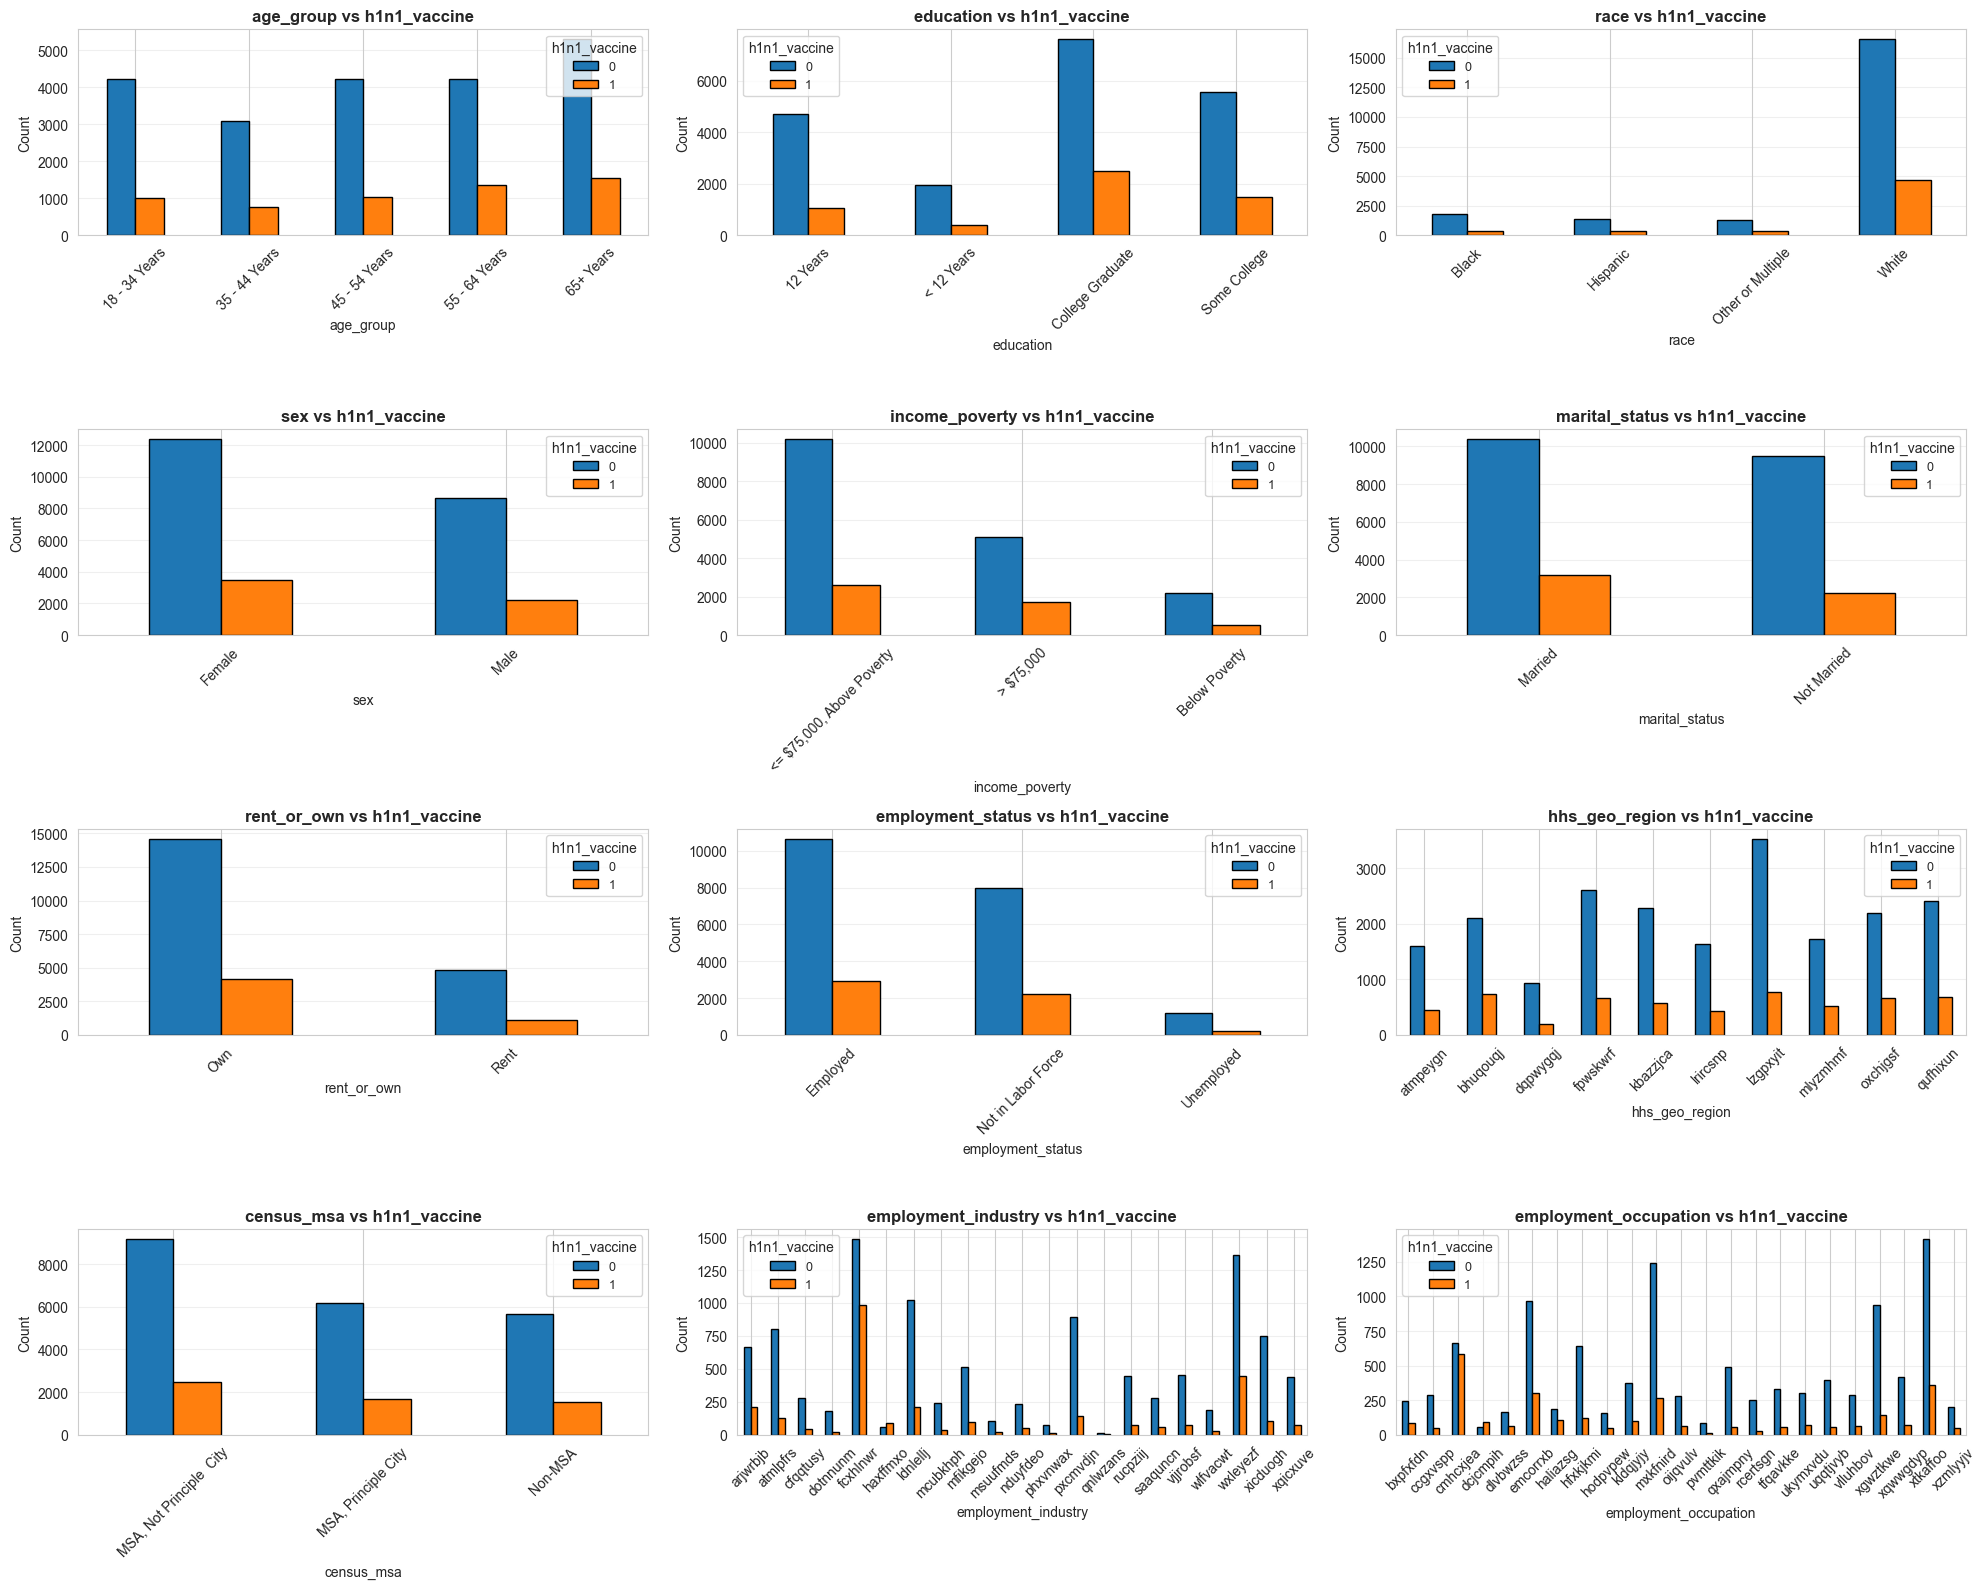

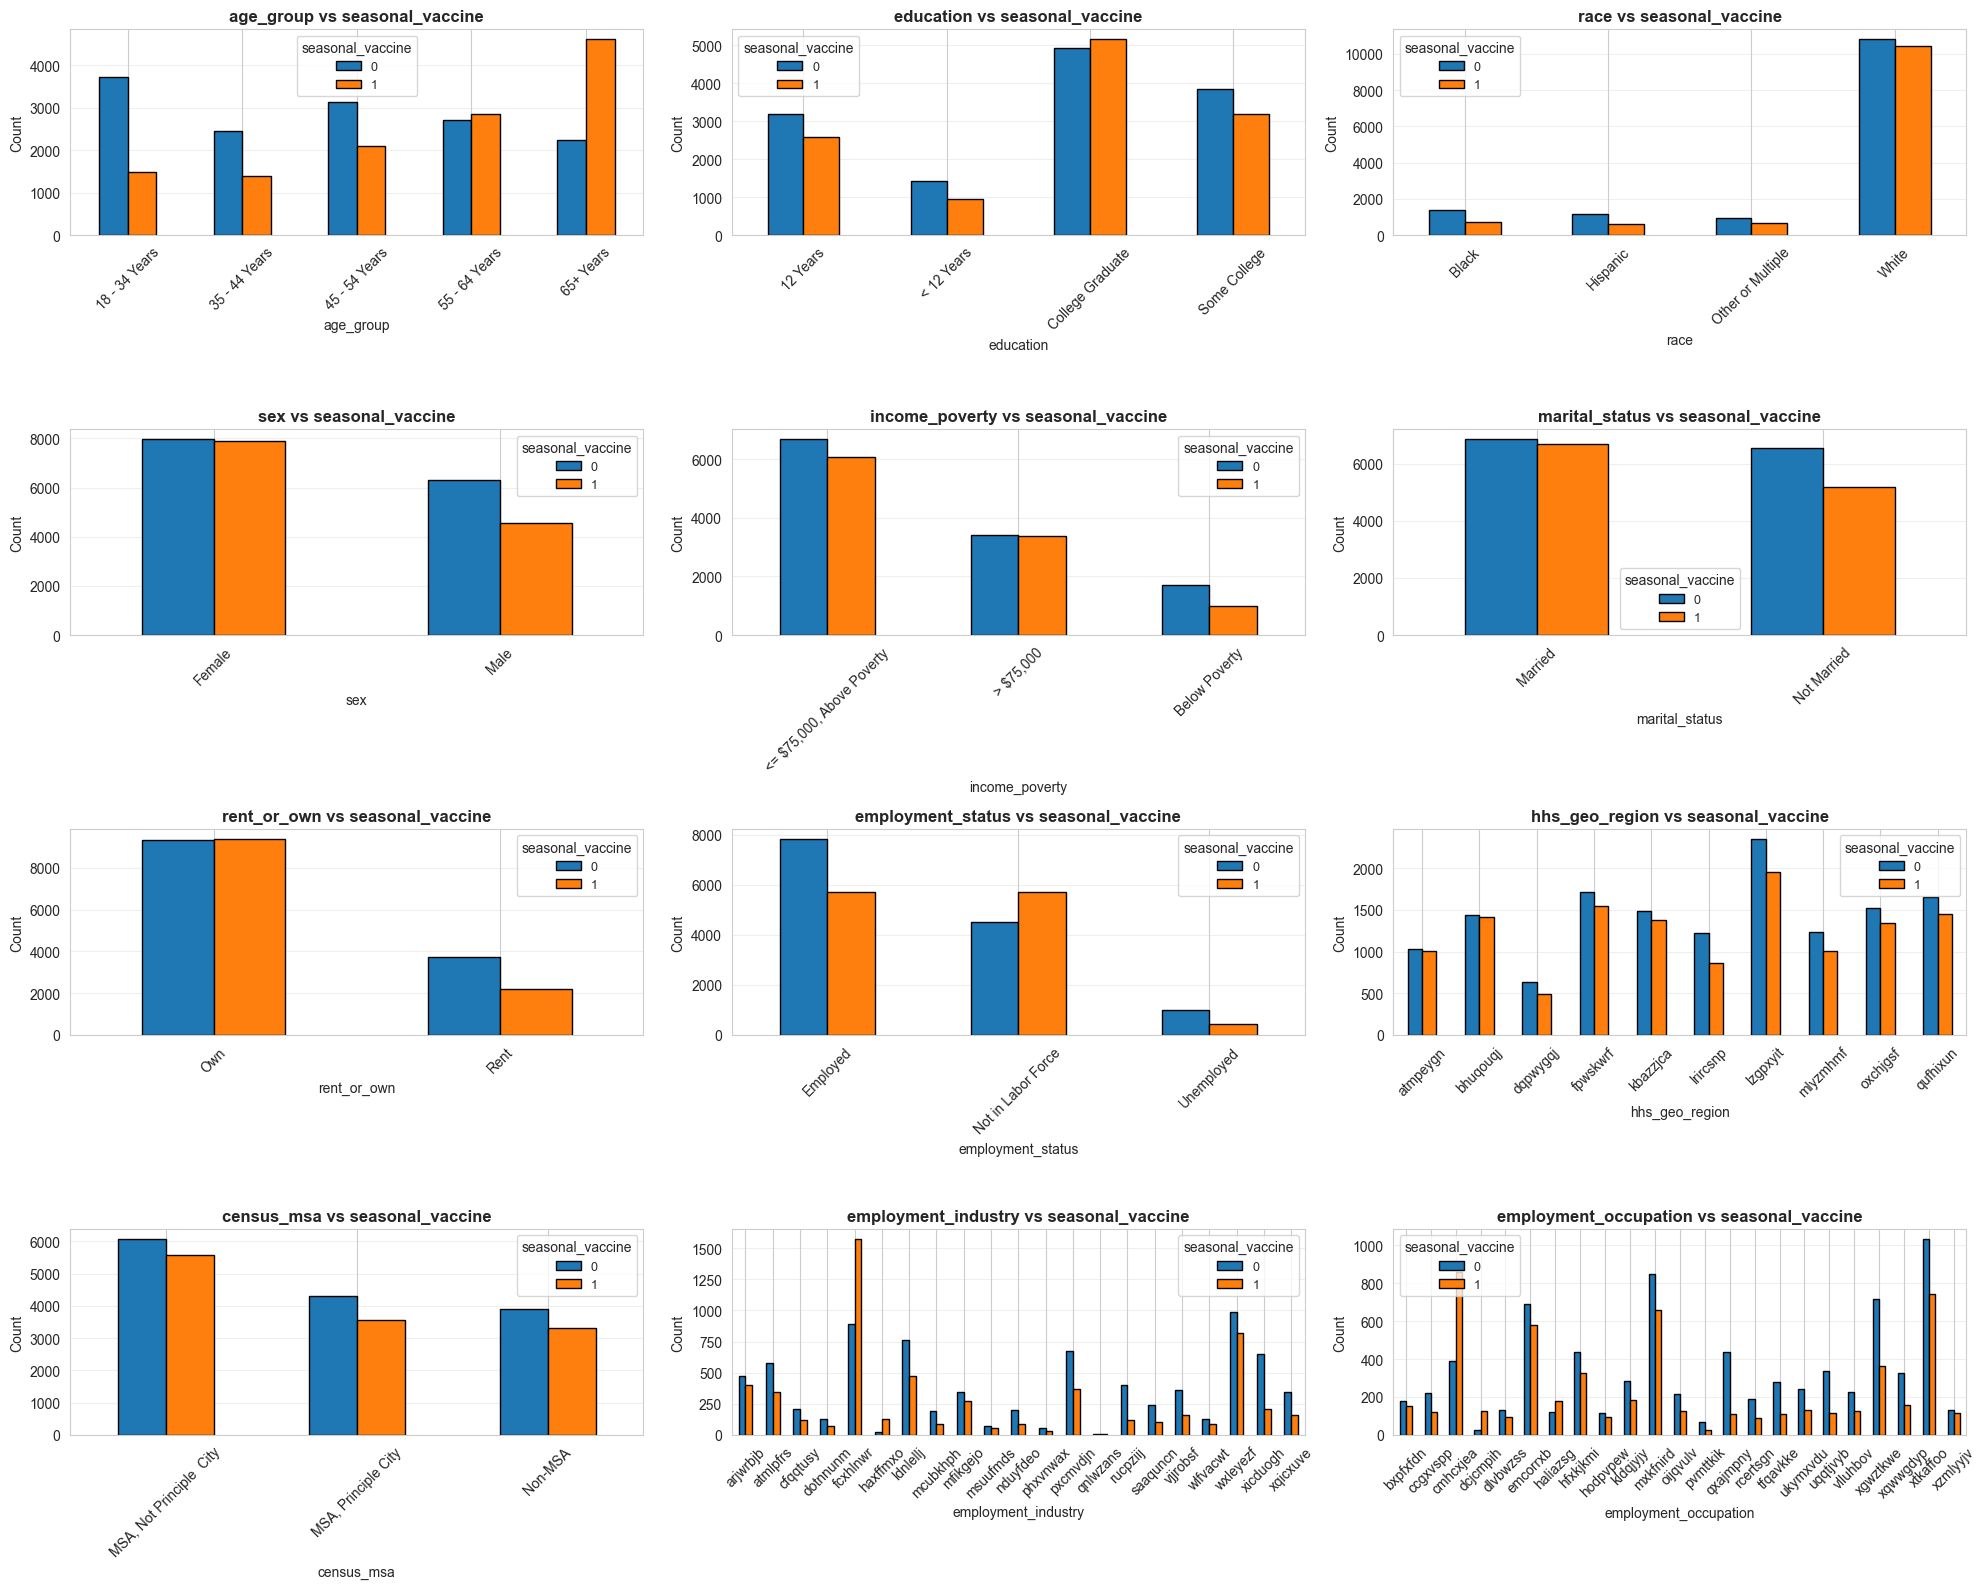

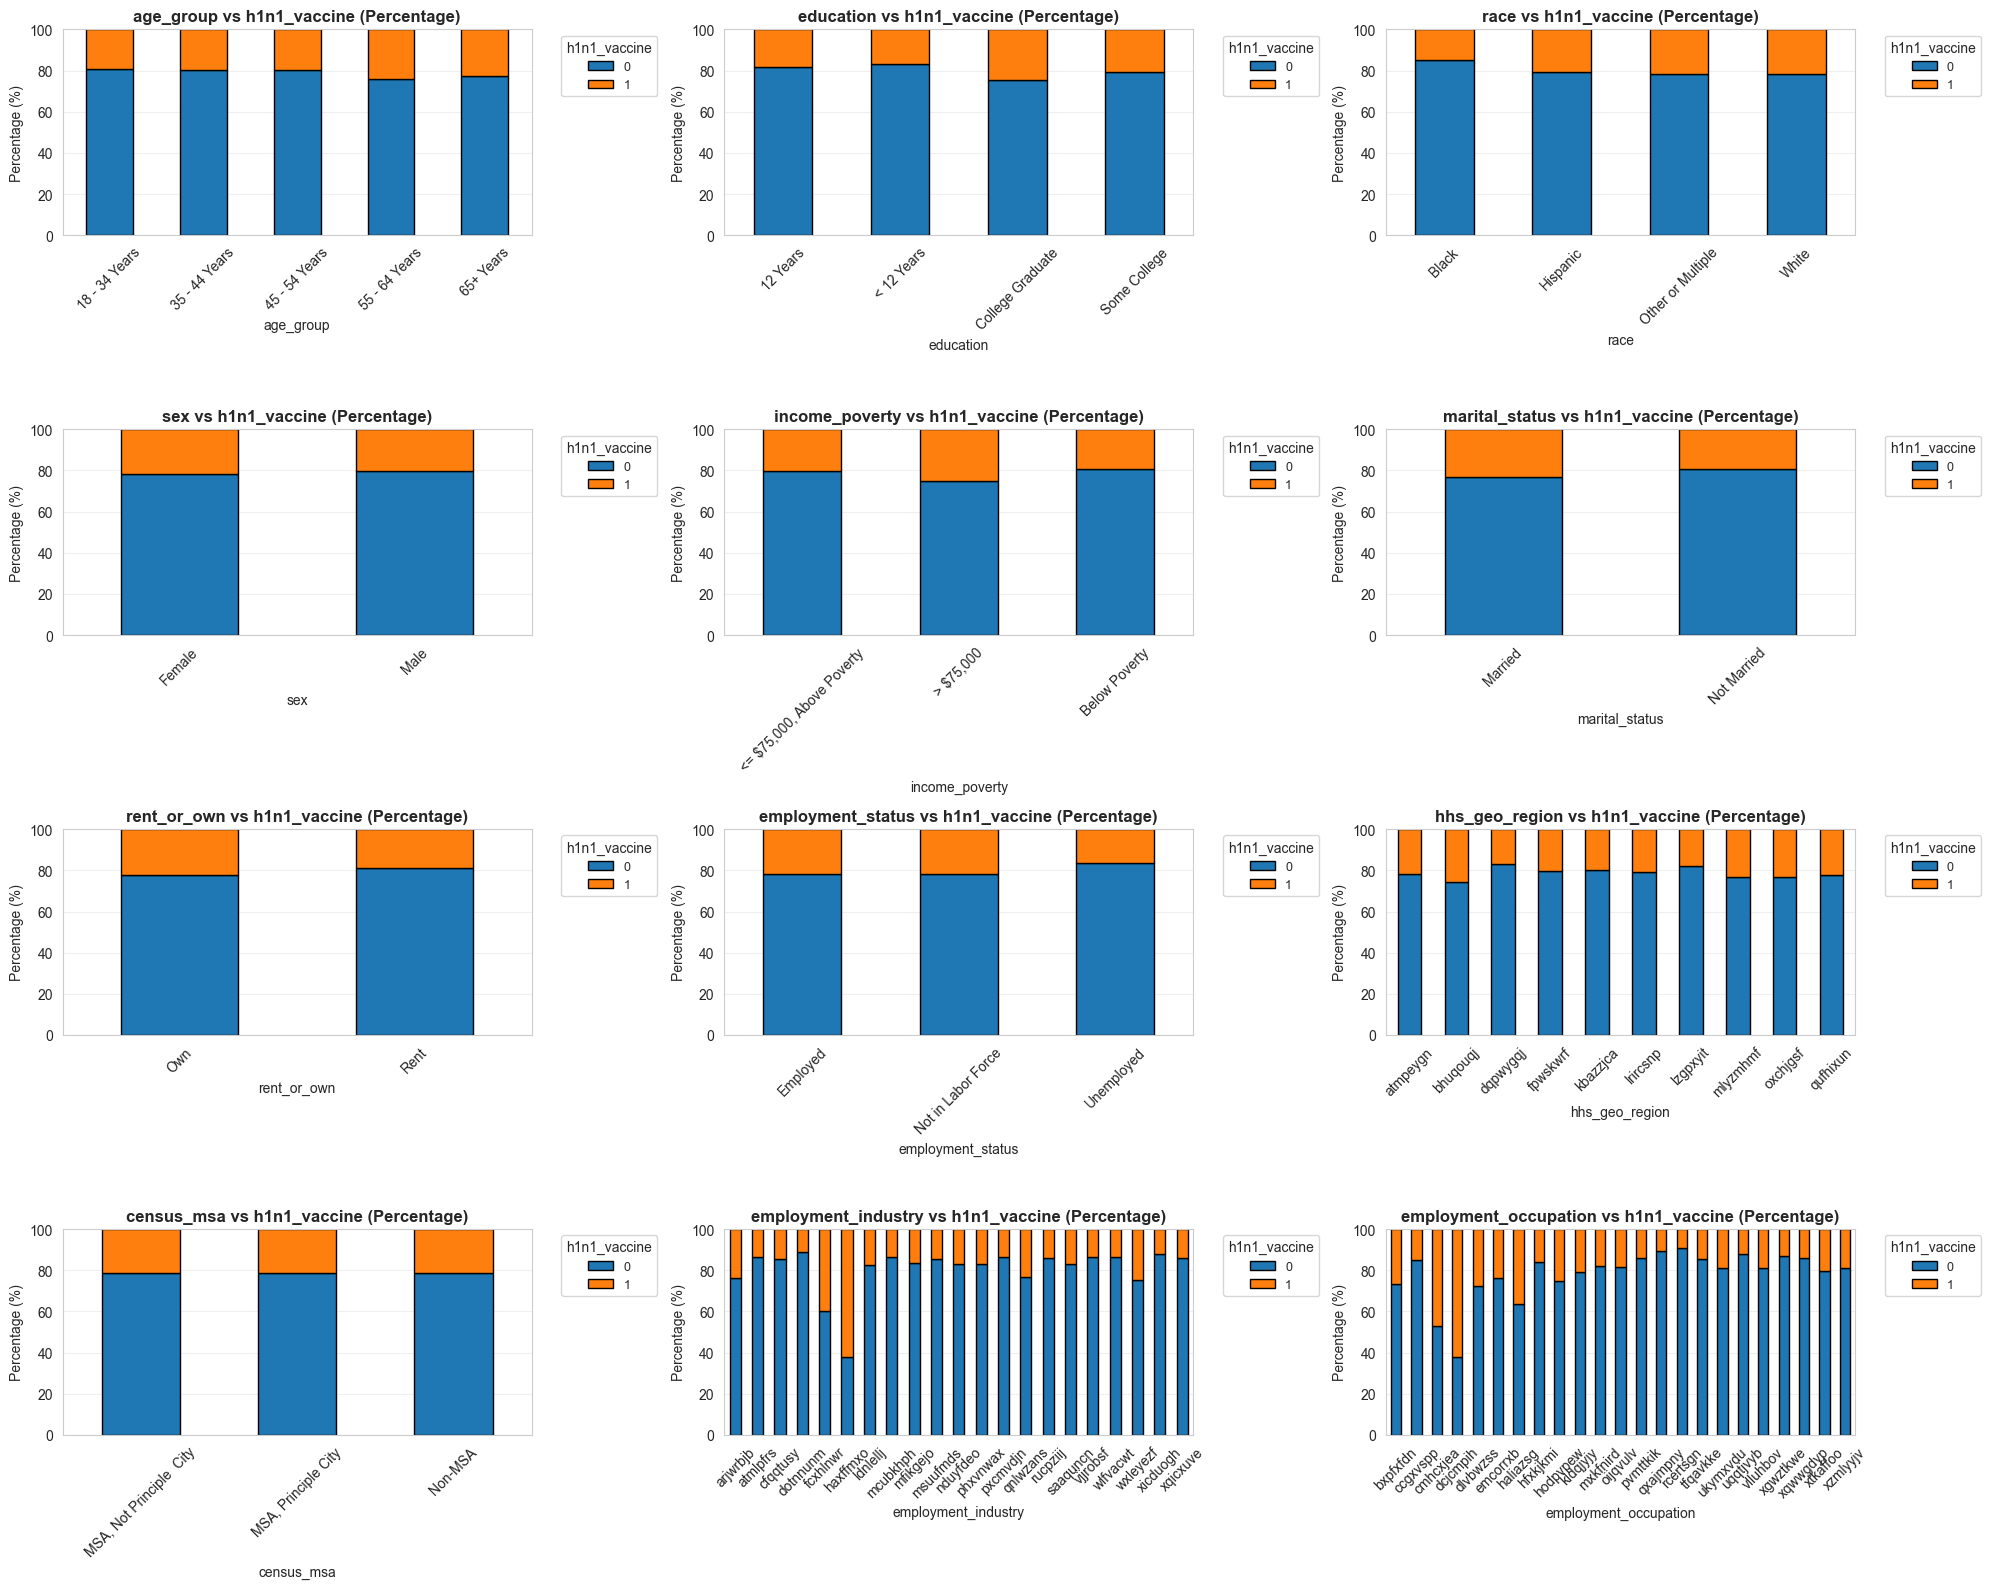

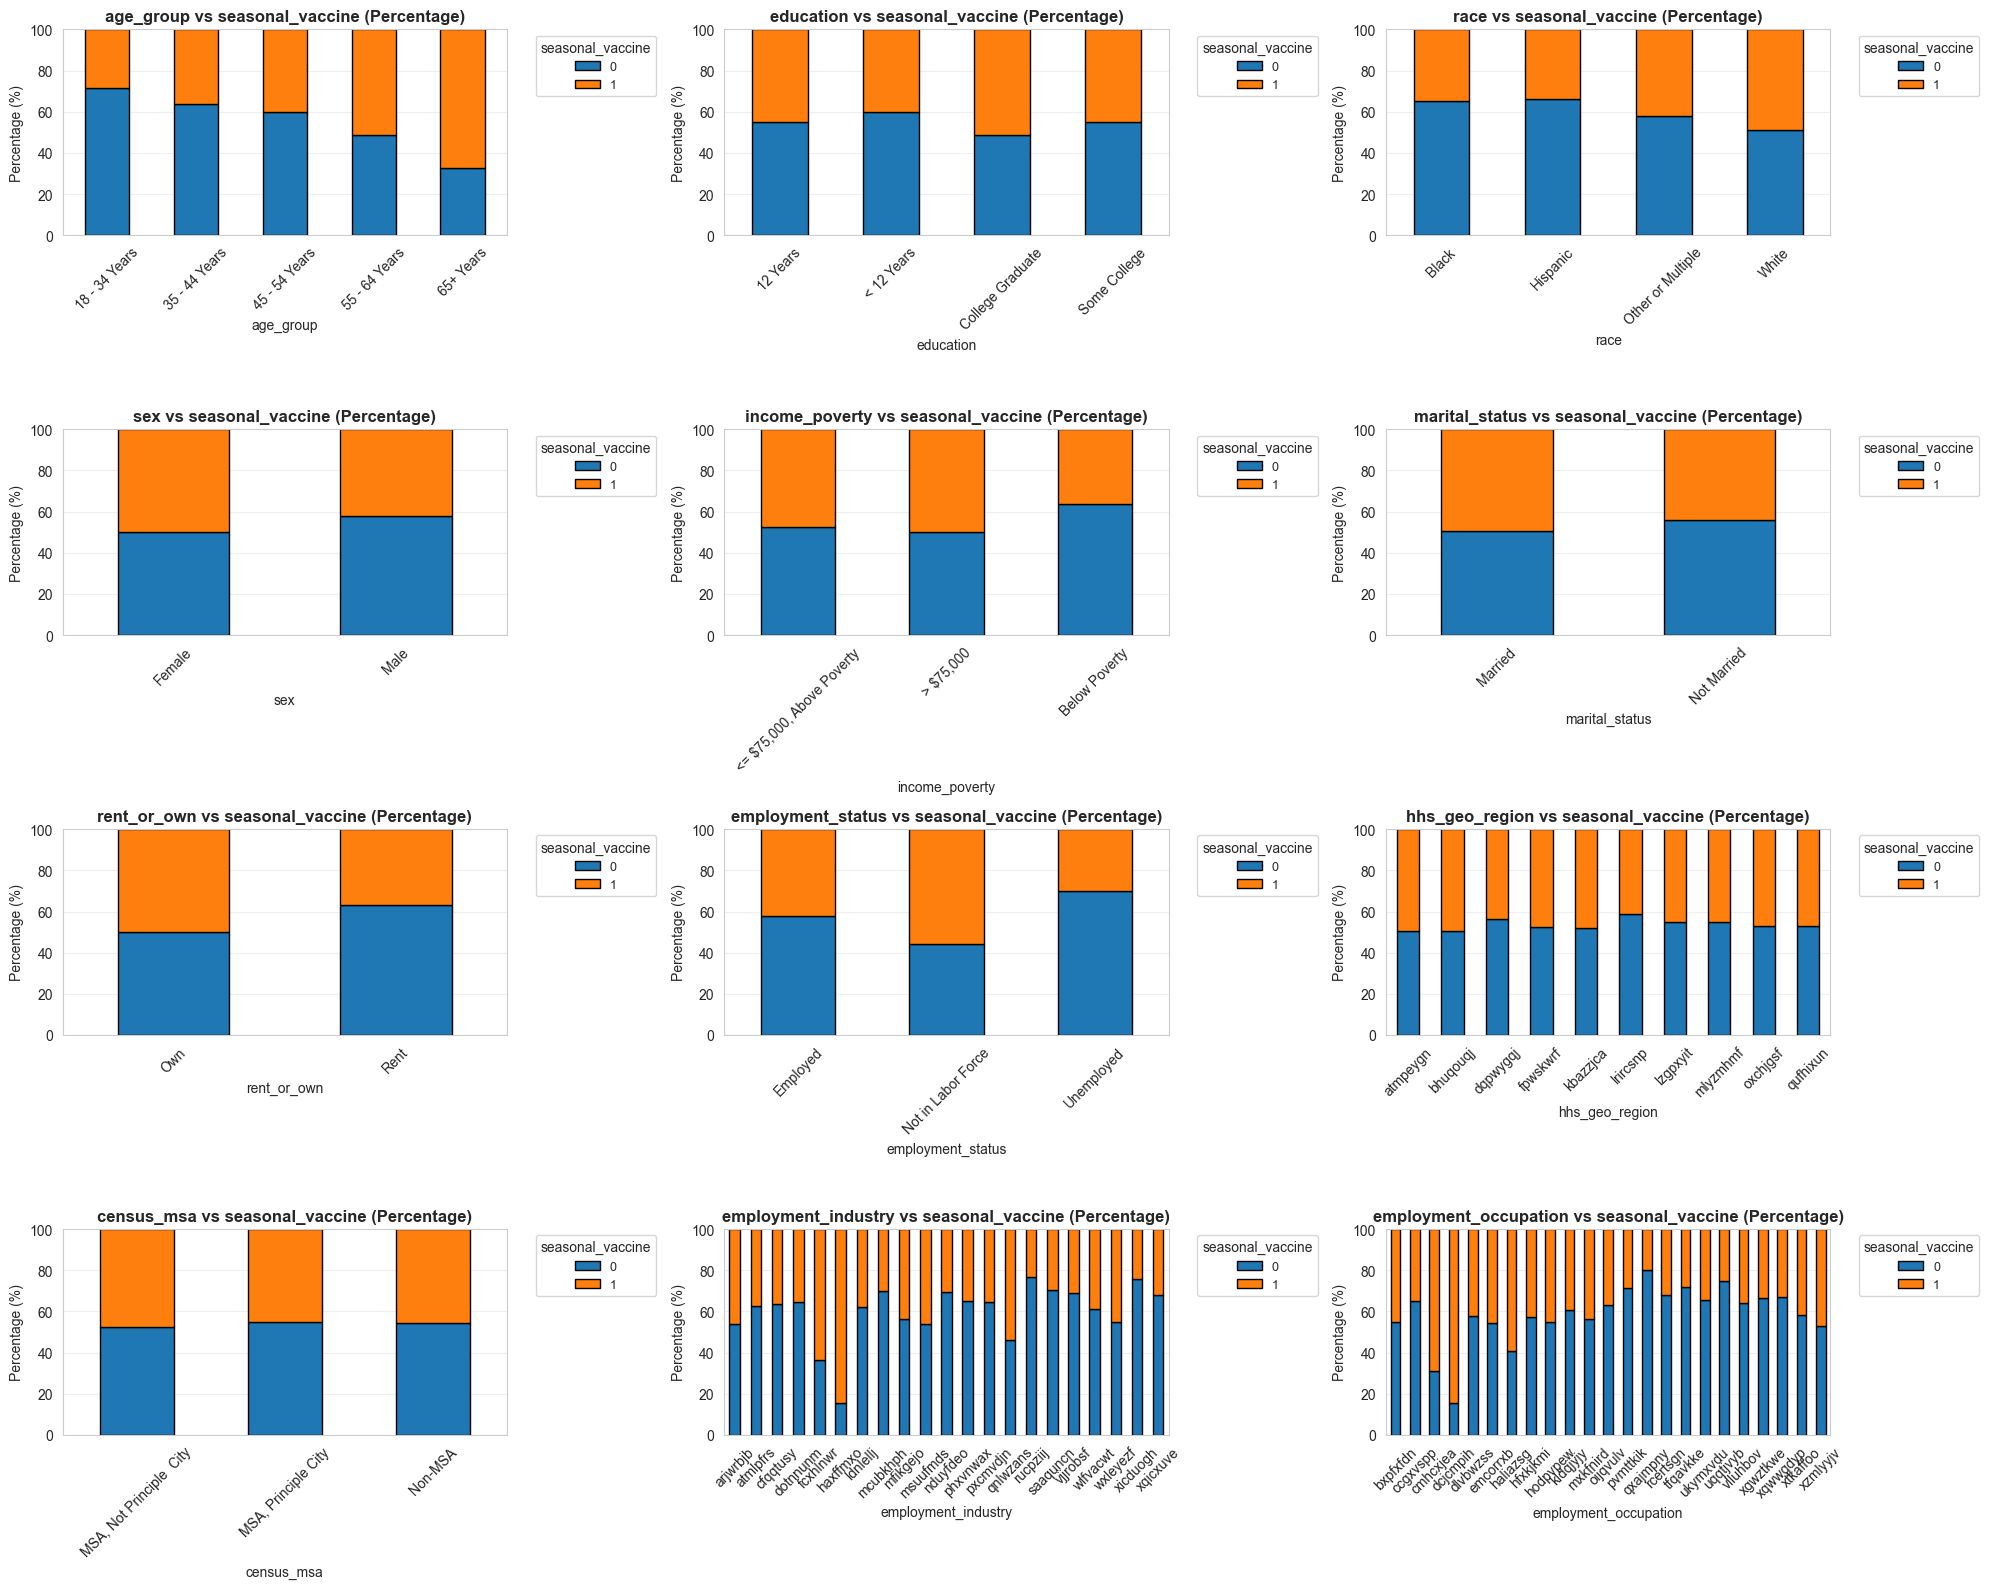


11. GENERATING HEATMAPS...


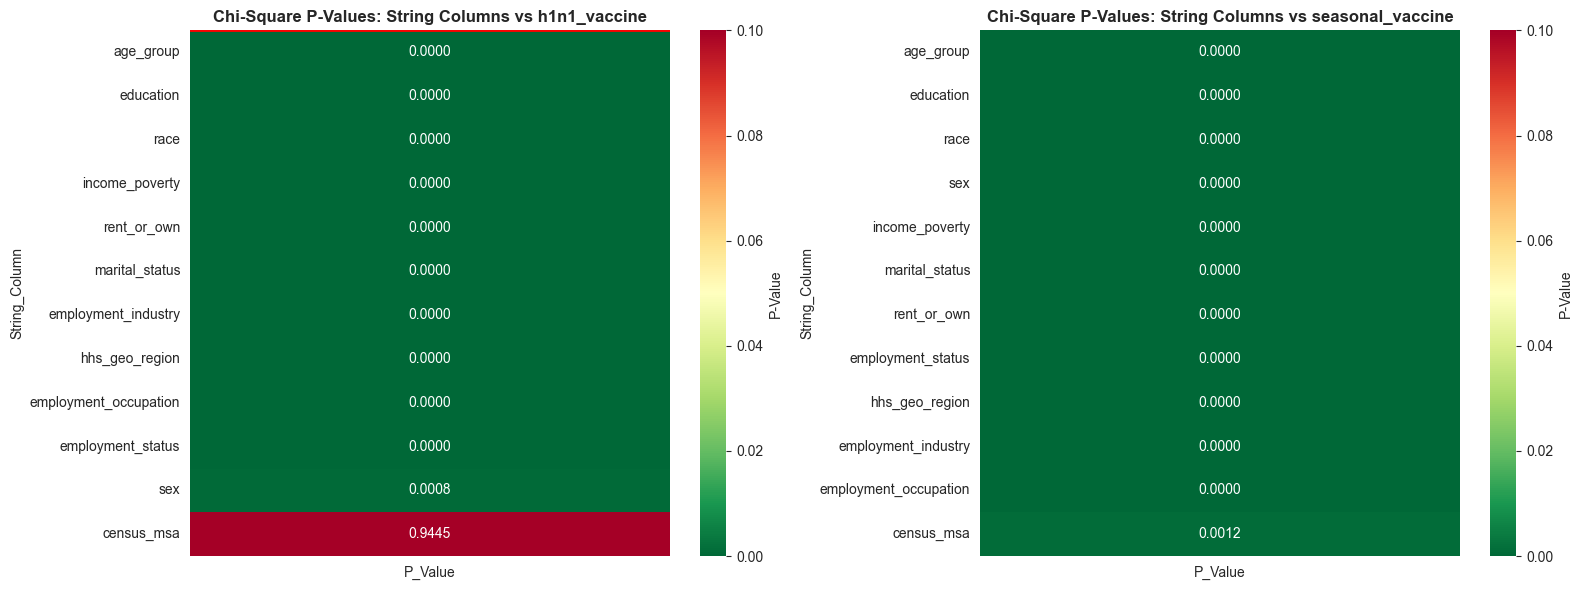

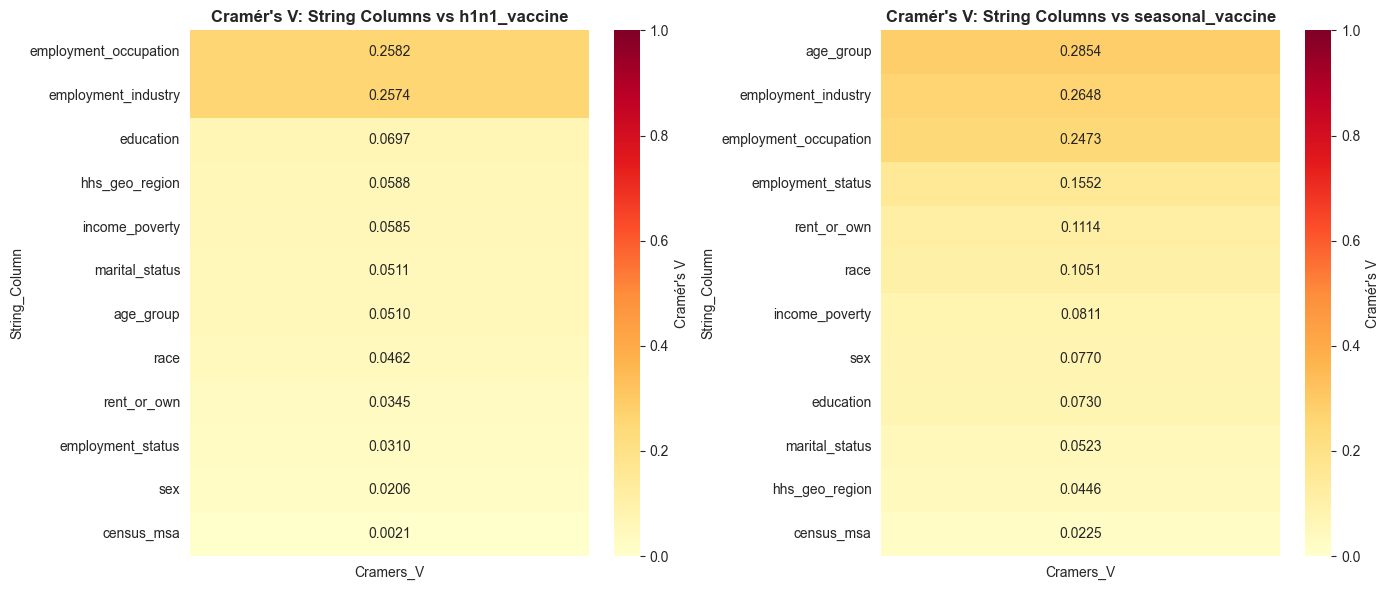


13. COMPARISON: H1N1 vs SEASONAL TARGETS

        String_Column  H1N1_Cramers_V  Seasonal_Cramers_V  Difference
employment_occupation          0.2582              0.2473      0.0109
  employment_industry          0.2574              0.2648      0.0074
            education          0.0697              0.0730      0.0033
       hhs_geo_region          0.0588              0.0446      0.0142
       income_poverty          0.0585              0.0811      0.0226
       marital_status          0.0511              0.0523      0.0012
            age_group          0.0510              0.2854      0.2344
                 race          0.0462              0.1051      0.0589
          rent_or_own          0.0345              0.1114      0.0769
    employment_status          0.0310              0.1552      0.1242
                  sex          0.0206              0.0770      0.0564
           census_msa          0.0021              0.0225      0.0204

14. SUMMARY & RECOMMENDATIONS

STRING COLUMNS 

In [8]:


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# ============================================================
# 1. IDENTIFY STRING COLUMNS
# ============================================================
print("="*80)
print("1. IDENTIFYING STRING COLUMNS")
print("="*80)

string_cols = merged_df.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal String Columns: {len(string_cols)}")
print("\nString Columns:")
for col in string_cols:
    print(f"  - {col}")

# Define targets
target_h1n1 = 'h1n1_vaccine'
target_seasonal = 'seasonal_vaccine'

# ============================================================
# 2. VALUE COUNTS FOR EACH STRING COLUMN
# ============================================================
print("\n" + "="*80)
print("2. VALUE COUNTS FOR STRING COLUMNS")
print("="*80)

for col in string_cols:
    print(f"\n{col}:")
    print("-" * 60)
    print(merged_df[col].value_counts(dropna=False))
    print(f"Unique Values: {merged_df[col].nunique()}")
    print(f"Missing Values: {merged_df[col].isnull().sum()}")

# ============================================================
# 3. CROSS-TABULATION: STRING COLUMNS vs H1N1 VACCINE
# ============================================================
print("\n" + "="*80)
print("3. CROSS-TABULATION: STRING COLUMNS vs H1N1 VACCINE")
print("="*80)

for col in string_cols:
    print(f"\n{col} vs {target_h1n1}:")
    print("-" * 80)
    crosstab = pd.crosstab(merged_df[col], merged_df[target_h1n1], margins=True)
    print(crosstab)
    
    # Calculate percentages
    print(f"\nPercentage Distribution:")
    crosstab_pct = pd.crosstab(merged_df[col], merged_df[target_h1n1], normalize='index') * 100
    print(crosstab_pct.round(2))

# ============================================================
# 4. CROSS-TABULATION: STRING COLUMNS vs SEASONAL VACCINE
# ============================================================
print("\n" + "="*80)
print("4. CROSS-TABULATION: STRING COLUMNS vs SEASONAL VACCINE")
print("="*80)

for col in string_cols:
    print(f"\n{col} vs {target_seasonal}:")
    print("-" * 80)
    crosstab = pd.crosstab(merged_df[col], merged_df[target_seasonal], margins=True)
    print(crosstab)
    
    # Calculate percentages
    print(f"\nPercentage Distribution:")
    crosstab_pct = pd.crosstab(merged_df[col], merged_df[target_seasonal], normalize='index') * 100
    print(crosstab_pct.round(2))

# ============================================================
# 5. CHI-SQUARE TEST: STRING COLUMNS vs TARGETS
# ============================================================
print("\n" + "="*80)
print("5. CHI-SQUARE TEST (Independence Test)")
print("="*80)
print("(p-value < 0.05 suggests relationship between variables)")
print("="*80)

from scipy.stats import chi2_contingency

chi_square_results_h1n1 = []
chi_square_results_seasonal = []

for col in string_cols:
    # Remove null values for chi-square test
    clean_data = merged_df[[col, target_h1n1, target_seasonal]].dropna()
    
    # H1N1 Test
    crosstab_h1n1 = pd.crosstab(clean_data[col], clean_data[target_h1n1])
    chi2_h1n1, p_h1n1, dof_h1n1, expected_h1n1 = chi2_contingency(crosstab_h1n1)
    
    chi_square_results_h1n1.append({
        'String_Column': col,
        'Chi2_Statistic': round(chi2_h1n1, 4),
        'P_Value': round(p_h1n1, 6),
        'Significant': "Yes" if p_h1n1 < 0.05 else "No",
        'DOF': dof_h1n1
    })
    
    # Seasonal Test
    crosstab_seasonal = pd.crosstab(clean_data[col], clean_data[target_seasonal])
    chi2_seasonal, p_seasonal, dof_seasonal, expected_seasonal = chi2_contingency(crosstab_seasonal)
    
    chi_square_results_seasonal.append({
        'String_Column': col,
        'Chi2_Statistic': round(chi2_seasonal, 4),
        'P_Value': round(p_seasonal, 6),
        'Significant': "Yes" if p_seasonal < 0.05 else "No",
        'DOF': dof_seasonal
    })

chi2_df_h1n1 = pd.DataFrame(chi_square_results_h1n1).sort_values('P_Value')
chi2_df_seasonal = pd.DataFrame(chi_square_results_seasonal).sort_values('P_Value')

print(f"\nCHI-SQUARE TEST WITH H1N1 VACCINE:")
print(chi2_df_h1n1.to_string(index=False))

print(f"\n\nCHI-SQUARE TEST WITH SEASONAL VACCINE:")
print(chi2_df_seasonal.to_string(index=False))

# ============================================================
# 6. CRAMÉR'S V: EFFECT SIZE FOR STRING COLUMNS
# ============================================================
print("\n" + "="*80)
print("6. CRAMÉR'S V - ASSOCIATION STRENGTH (0 to 1)")
print("="*80)
print("0 = No association, 1 = Perfect association")
print("0.1-0.3 = Small, 0.3-0.5 = Medium, >0.5 = Large")
print("="*80)

def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

cramers_h1n1 = []
cramers_seasonal = []

for col in string_cols:
    clean_data = merged_df[[col, target_h1n1, target_seasonal]].dropna()
    
    v_h1n1 = cramers_v(clean_data[col], clean_data[target_h1n1])
    v_seasonal = cramers_v(clean_data[col], clean_data[target_seasonal])
    
    # Classify effect size
    def effect_size(v):
        if v < 0.1:
            return "Negligible"
        elif v < 0.3:
            return "Small"
        elif v < 0.5:
            return "Medium"
        else:
            return "Large"
    
    cramers_h1n1.append({
        'String_Column': col,
        'Cramers_V': round(v_h1n1, 4),
        'Effect_Size': effect_size(v_h1n1)
    })
    
    cramers_seasonal.append({
        'String_Column': col,
        'Cramers_V': round(v_seasonal, 4),
        'Effect_Size': effect_size(v_seasonal)
    })

cramers_h1n1_df = pd.DataFrame(cramers_h1n1).sort_values('Cramers_V', ascending=False)
cramers_seasonal_df = pd.DataFrame(cramers_seasonal).sort_values('Cramers_V', ascending=False)

print(f"\nCRAMÉR'S V WITH H1N1 VACCINE:")
print(cramers_h1n1_df.to_string(index=False))

print(f"\n\nCRAMÉR'S V WITH SEASONAL VACCINE:")
print(cramers_seasonal_df.to_string(index=False))

# ============================================================
# 7. VISUALIZATION: STACKED BAR CHARTS - H1N1 VACCINE
# ============================================================
print("\n" + "="*80)
print("7. GENERATING VISUALIZATIONS...")
print("="*80)

n_cols = len(string_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_h1n1])
    crosstab.plot(kind='bar', ax=axes[idx], stacked=False, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_h1n1}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].legend(title=target_h1n1, fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_h1n1_vaccine.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 8. VISUALIZATION: STACKED BAR CHARTS - SEASONAL VACCINE
# ============================================================

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_seasonal])
    crosstab.plot(kind='bar', ax=axes[idx], stacked=False, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_seasonal}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    axes[idx].legend(title=target_seasonal, fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_seasonal_vaccine.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 9. VISUALIZATION: PERCENTAGE STACKED BAR CHARTS - H1N1
# ============================================================

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_h1n1], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], stacked=True, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_h1n1} (Percentage)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(title=target_h1n1, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim([0, 100])

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_h1n1_vaccine_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 10. VISUALIZATION: PERCENTAGE STACKED BAR CHARTS - SEASONAL
# ============================================================

fig, axes = plt.subplots(n_rows, 3, figsize=(20, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(string_cols):
    crosstab = pd.crosstab(merged_df[col], merged_df[target_seasonal], normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[idx], stacked=True, edgecolor='black')
    axes[idx].set_title(f'{col} vs {target_seasonal} (Percentage)', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].legend(title=target_seasonal, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_ylim([0, 100])

# Hide extra subplots
for idx in range(len(string_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('EDA_plots/string_cols_vs_seasonal_vaccine_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 11. HEATMAP: CHI-SQUARE P-VALUES
# ============================================================

print("\n11. GENERATING HEATMAPS...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for heatmap
chi2_pivot_h1n1 = chi2_df_h1n1.set_index('String_Column')[['P_Value']]
chi2_pivot_seasonal = chi2_df_seasonal.set_index('String_Column')[['P_Value']]

# H1N1 Heatmap
sns.heatmap(chi2_pivot_h1n1, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'P-Value'}, ax=axes[0], vmin=0, vmax=0.1)
axes[0].set_title(f'Chi-Square P-Values: String Columns vs {target_h1n1}', 
                  fontsize=12, fontweight='bold')
axes[0].axhline(y=0, color='red', linewidth=2)

# Seasonal Heatmap
sns.heatmap(chi2_pivot_seasonal, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'P-Value'}, ax=axes[1], vmin=0, vmax=0.1)
axes[1].set_title(f'Chi-Square P-Values: String Columns vs {target_seasonal}', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/chi_square_pvalues_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 12. HEATMAP: CRAMÉR'S V VALUES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cramers_pivot_h1n1 = cramers_h1n1_df.set_index('String_Column')[['Cramers_V']]
cramers_pivot_seasonal = cramers_seasonal_df.set_index('String_Column')[['Cramers_V']]

sns.heatmap(cramers_pivot_h1n1, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': "Cramér's V"}, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title(f"Cramér's V: String Columns vs {target_h1n1}", 
                  fontsize=12, fontweight='bold')

sns.heatmap(cramers_pivot_seasonal, annot=True, fmt='.4f', cmap='YlOrRd', 
            cbar_kws={'label': "Cramér's V"}, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title(f"Cramér's V: String Columns vs {target_seasonal}", 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('EDA_plots/cramers_v_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# 13. COMPARISON: H1N1 vs SEASONAL TARGETS
# ============================================================
print("\n" + "="*80)
print("13. COMPARISON: H1N1 vs SEASONAL TARGETS")
print("="*80)

comparison_df = pd.DataFrame({
    'String_Column': cramers_h1n1_df['String_Column'],
    'H1N1_Cramers_V': cramers_h1n1_df['Cramers_V'].values,
    'Seasonal_Cramers_V': cramers_seasonal_df.set_index('String_Column').loc[
        cramers_h1n1_df['String_Column'], 'Cramers_V'].values,
})

comparison_df['Difference'] = abs(comparison_df['H1N1_Cramers_V'] - comparison_df['Seasonal_Cramers_V'])
comparison_df = comparison_df.sort_values('H1N1_Cramers_V', ascending=False)

print("\n" + comparison_df.to_string(index=False))

# ============================================================
# 14. SUMMARY & RECOMMENDATIONS
# ============================================================
print("\n" + "="*80)
print("14. SUMMARY & RECOMMENDATIONS")
print("="*80)

significant_h1n1 = chi2_df_h1n1[chi2_df_h1n1['Significant'] == 'Yes']
significant_seasonal = chi2_df_seasonal[chi2_df_seasonal['Significant'] == 'Yes']

strong_h1n1 = cramers_h1n1_df[cramers_h1n1_df['Effect_Size'].isin(['Large', 'Medium'])]['String_Column'].tolist()
strong_seasonal = cramers_seasonal_df[cramers_seasonal_df['Effect_Size'].isin(['Large', 'Medium'])]['String_Column'].tolist()

print(f"""
STRING COLUMNS ANALYSIS RESULTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 SIGNIFICANT ASSOCIATIONS (Chi-Square p < 0.05):

H1N1 VACCINE:
  • Count: {len(significant_h1n1)} columns
  • Columns: {', '.join(significant_h1n1['String_Column'].tolist())}

SEASONAL VACCINE:
  • Count: {len(significant_seasonal)} columns
  • Columns: {', '.join(significant_seasonal['String_Column'].tolist())}

💪 STRONG PREDICTORS (Cramér's V > 0.3):

H1N1 VACCINE:
  • Columns: {', '.join(strong_h1n1) if strong_h1n1 else 'None'}

SEASONAL VACCINE:
  • Columns: {', '.join(strong_seasonal) if strong_seasonal else 'None'}

🎯 TOP 3 FEATURES FOR EACH TARGET:

H1N1 VACCINE:
{cramers_h1n1_df.head(3)[['String_Column', 'Cramers_V', 'Effect_Size']].to_string(index=False)}

SEASONAL VACCINE:
{cramers_seasonal_df.head(3)[['String_Column', 'Cramers_V', 'Effect_Size']].to_string(index=False)}

📌 RECOMMENDATIONS:
  1. Keep columns with p < 0.05 (statistically significant)
  2. Prioritize columns with Cramér's V > 0.3 for modeling
  3. Use one-hot encoding for categorical variables before model building
  4. Consider dropping columns with negligible association (Cramér's V < 0.1)
  5. Both targets show similar patterns - features are generally consistent
""")

# ============================================================
# 15. EXPORT RESULTS TO CSV
# ============================================================

chi2_df_h1n1.to_csv('analysis_results_csv/chi_square_h1n1.csv', index=False)
chi2_df_seasonal.to_csv('analysis_results_csv/chi_square_seasonal.csv', index=False)
cramers_h1n1_df.to_csv('analysis_results_csv/cramers_v_h1n1.csv', index=False)
cramers_seasonal_df.to_csv('analysis_results_csv/cramers_v_seasonal.csv', index=False)
comparison_df.to_csv('analysis_results_csv/h1n1_vs_seasonal_comparison.csv', index=False)

print("\n✓ Results exported to CSV files:")
print("  - chi_square_h1n1.csv")
print("  - chi_square_seasonal.csv")
print("  - cramers_v_h1n1.csv")
print("  - cramers_v_seasonal.csv")
print("  - h1n1_vs_seasonal_comparison.csv")

PART 1: MISSING DATA OVERVIEW

employment_occupation Missing Data:
  Total rows: 26707
  Missing: 13470 (50.44%)
  Non-missing: 13237

PART 2: MISSING RATES BY GROUP

EMPLOYMENT_STATUS:
                    Has Value  Missing  Total  Missing %
employment_status                                       
Employed                13237      323  13560       2.38
Not in Labor Force          0    10231  10231     100.00
Unemployed                  0     1453   1453     100.00

EDUCATION:
                  Has Value  Missing  Total  Missing %
education                                             
12 Years               2435     3362   5797      58.00
< 12 Years              713     1650   2363      69.83
College Graduate       6444     3653  10097      36.18
Some College           3596     3447   7043      48.94

INCOME_POVERTY:
                           Has Value  Missing  Total  Missing %
income_poverty                                                 
<= $75,000, Above Poverty       6450     6

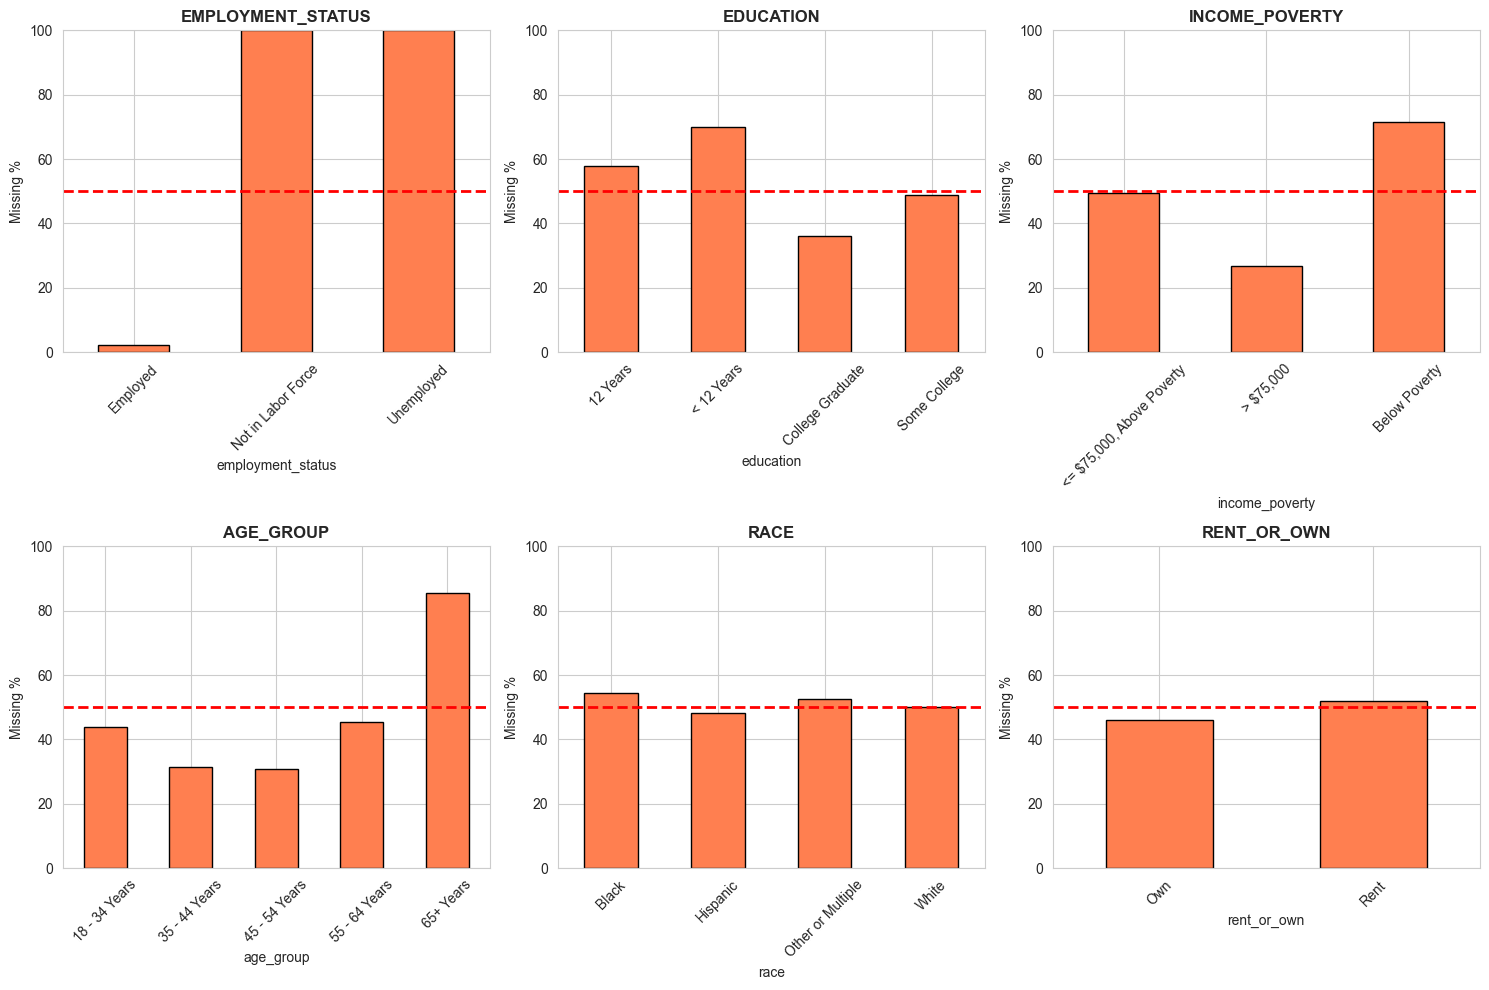

In [10]:


# CONFIGURATION
variables_to_check = ['employment_status', 'education', 'income_poverty', 
                      'age_group', 'race', 'rent_or_own']

# Assuming merged_df is already loaded
# If not, uncomment the line below:
# merged_df = pd.read_csv('your_data.csv')

# Create missing flag
merged_df['employment_occupation_missing'] = merged_df['employment_occupation'].isnull().astype(int)

# ===== 1. BASIC SUMMARY =====
print("="*60)
print("PART 1: MISSING DATA OVERVIEW")
print("="*60)

missing_count = merged_df['employment_occupation'].isnull().sum()
missing_rate = (missing_count / len(merged_df)) * 100

print(f"\nemployment_occupation Missing Data:")
print(f"  Total rows: {len(merged_df)}")
print(f"  Missing: {missing_count} ({missing_rate:.2f}%)")
print(f"  Non-missing: {len(merged_df) - missing_count}")

# ===== 2. MISSING RATES BY GROUP =====
print("\n" + "="*60)
print("PART 2: MISSING RATES BY GROUP")
print("="*60)

for var in variables_to_check:
    print(f"\n{var.upper()}:")
    missing_by_group = merged_df.groupby(var)['employment_occupation_missing'].agg([
        ('Has Value', lambda x: (x == 0).sum()),
        ('Missing', lambda x: (x == 1).sum()),
        ('Total', 'count'),
        ('Missing %', lambda x: (x.sum() / len(x) * 100).round(2))
    ])
    print(missing_by_group)

# ===== 3. CHI-SQUARE TESTS =====
print("\n" + "="*60)
print("PART 3: CHI-SQUARE TEST RESULTS")
print("="*60)

results = []

for var in variables_to_check:
    contingency = pd.crosstab(merged_df[var], merged_df['employment_occupation_missing'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"\n{var.upper()}: χ² = {chi2:.4f}, p-value = {p_value:.6f}", end="")
    
    if p_value < 0.05:
        print(" ✅ SIGNIFICANT")
        sig = "YES"
    else:
        print(" ❌ NOT SIGNIFICANT")
        sig = "NO"
    
    results.append({'Variable': var, 'Chi2': chi2, 'P-value': p_value, 'Significant': sig})

# ===== 4. SUMMARY TABLE =====
print("\n" + "="*60)
print("PART 4: SUMMARY TABLE")
print("="*60)

results_df = pd.DataFrame(results).sort_values('P-value')
print("\n" + results_df.to_string(index=False))

# ===== 5. FINAL RECOMMENDATION =====
print("\n" + "="*60)
print("FINAL RECOMMENDATION")
print("="*60)

significant_count = (results_df['P-value'] < 0.05).sum()

print(f"\nVariables related to missing: {significant_count}/6")
print(f"Missing percentage: {missing_rate:.2f}%")

if missing_rate > 50 and significant_count >= 2:
    print("\n🚨 RECOMMENDATION: EXCLUDE employment_occupation")
    print("   - Too much missing data (>50%)")
    print("   - Missing is NOT random (related to other variables)")
    print("   - Results would be BIASED if used")
elif missing_rate > 50:
    print("\n⚠️ RECOMMENDATION: EXCLUDE or use with caution")
    print("   - Too much missing data (>50%)")
elif significant_count >= 3:
    print("\n⚠️ RECOMMENDATION: EXCLUDE or use advanced methods")
    print("   - Missing is strongly related to other variables")
    print("   - Results would be biased")
else:
    print("\n✅ RECOMMENDATION: Can KEEP employment_occupation")
    print("   - Use listwise deletion or imputation")

print("\n" + "="*60)

# ===== 6. VISUALIZE =====
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, var in enumerate(variables_to_check):
    missing_rate_by_group = merged_df.groupby(var)['employment_occupation_missing'].apply(
        lambda x: (x.sum() / len(x) * 100)
    )
    missing_rate_by_group.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(var.upper(), fontweight='bold')
    axes[idx].set_ylabel('Missing %')
    axes[idx].axhline(y=50, color='red', linestyle='--', linewidth=2)
    axes[idx].set_ylim(0, 100)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('missing_pattern_analysis.png', dpi=300, bbox_inches='tight')
print("\n✅ Chart saved as 'missing_pattern_analysis.png'")
plt.show()

"Employed": ~1% missing
"Not in Labor Force": ~100% missing
"Unemployed": ~100% missing


AGE_GROUP - Strong pattern
"65+ Years": ~85% missing (retirees don't have occupation)
Younger ages: 30-43% missing

INCOME_POVERTY - Strong pattern
"Below Poverty": ~73% missing
"Above $75,000": ~27% missing
Lower income = more likely missing occupation

EDUCATION - Moderate pattern
Varies 37-71% missing
Some education levels have higher missing rates

FILLING MISSING OCCUPATION DATA WITH 'UNKNOWN OCCUPATION'

BEFORE:
Missing employment_occupation: 13470
Missing %: 50.44%

AFTER:
Missing employment_occupation: 0
Missing %: 0.00%

OCCUPATION VALUE COUNTS (INCLUDING UNKNOWN)

employment_occupation
Unknown Occupation    13470
xtkaffoo               1778
mxkfnird               1509
emcorrxb               1270
cmhcxjea               1247
xgwztkwe               1082
hfxkjkmi                766
qxajmpny                548
xqwwgdyp                485
kldqjyjy                469
uqqtjvyb                452
tfqavkke                388
ukymxvdu                372
vlluhbov                354
oijqvulv                344
ccgxvspp                341
bxpfxfdn                331
haliazsg                296
rcertsgn                276
xzmlyyjv                248
dlvbwzss                227
hodpvpew                208
dcjcmpih                148
pvmttkik                 98

OCCUPATION DISTRIBUTION BY EMPLOYMENT STATUS

employment_occupation  Unknown Oc

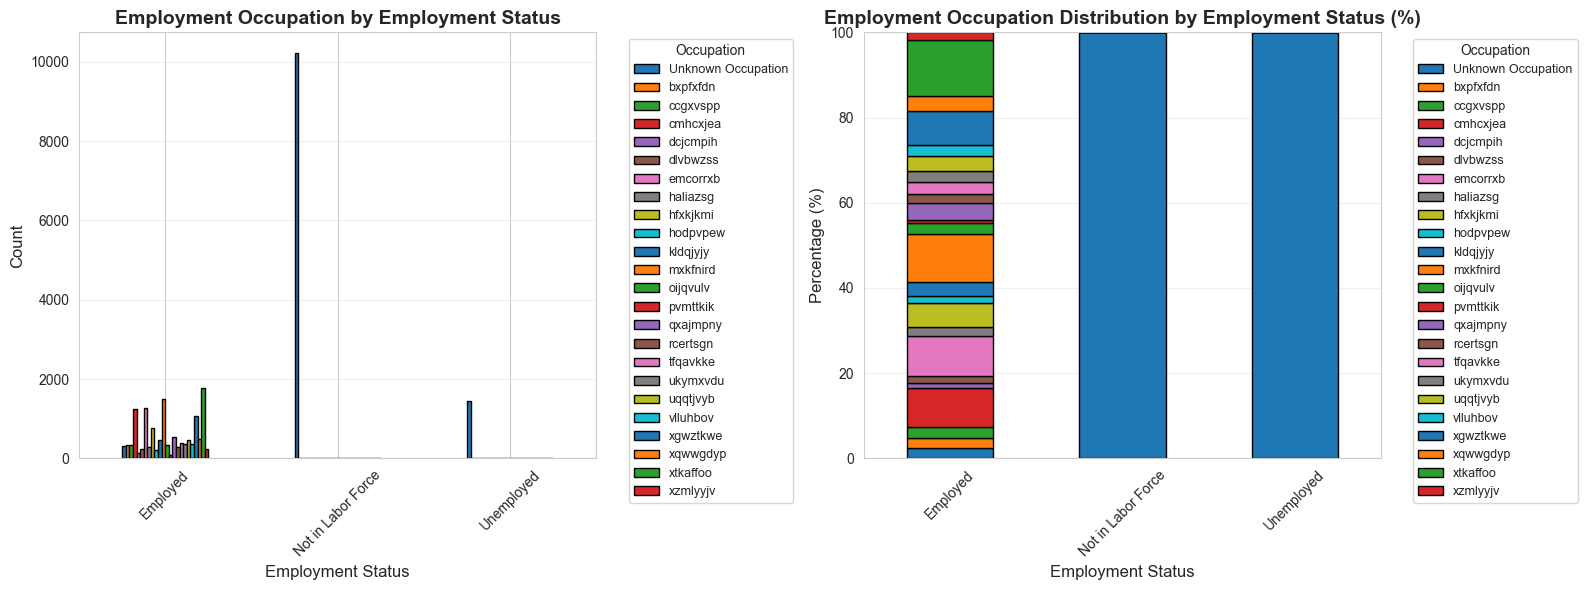

✅ Chart saved as 'occupation_filled_by_age.png'


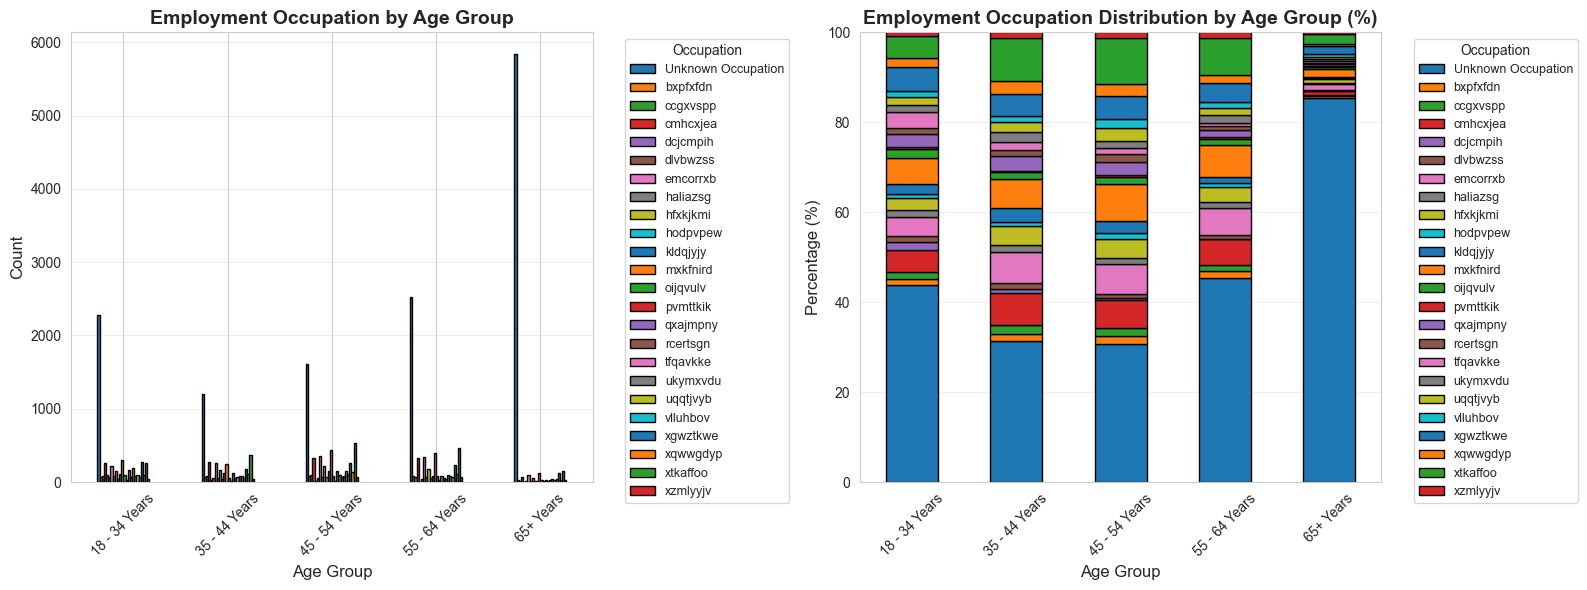

✅ Chart saved as 'top_occupations.png'


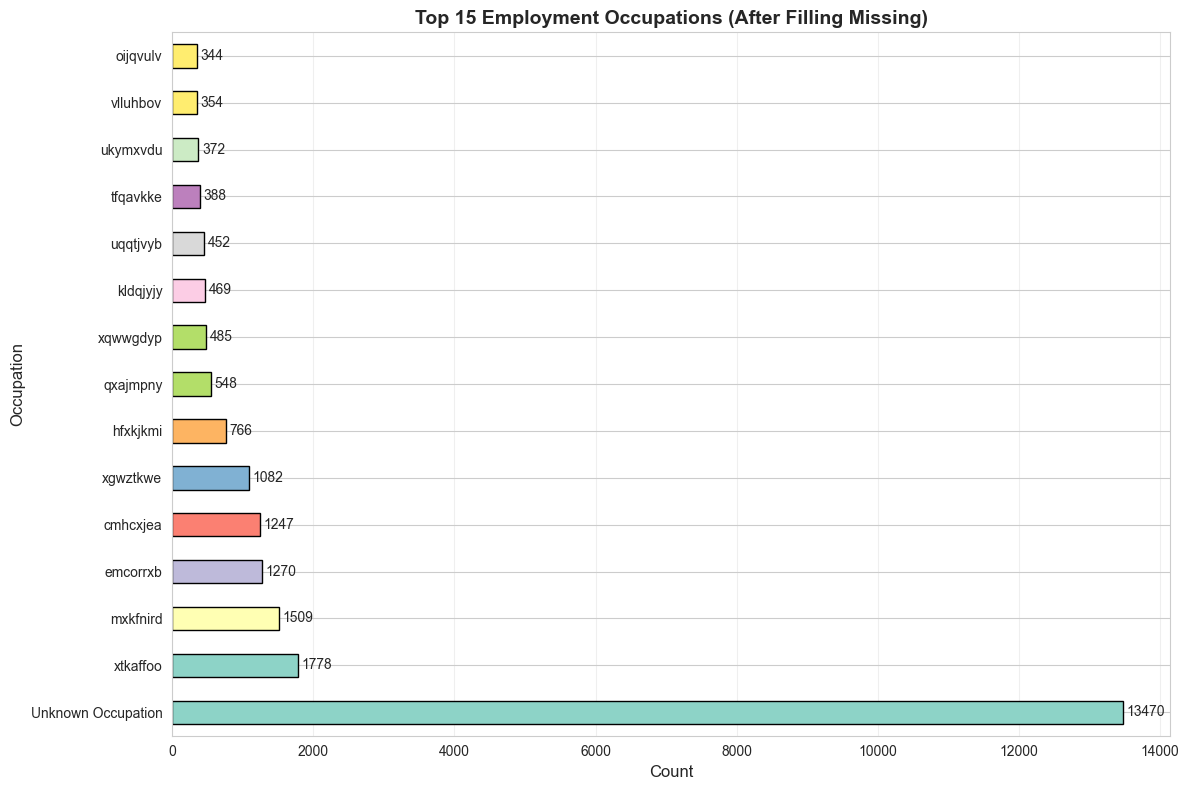


SUMMARY STATISTICS

Total Records: 26,707
Unique Occupations: 24

Occupation Counts:

   1. Unknown Occupation                                 : 13,470 (50.44%)
   2. xtkaffoo                                           :  1,778 ( 6.66%)
   3. mxkfnird                                           :  1,509 ( 5.65%)
   4. emcorrxb                                           :  1,270 ( 4.76%)
   5. cmhcxjea                                           :  1,247 ( 4.67%)
   6. xgwztkwe                                           :  1,082 ( 4.05%)
   7. hfxkjkmi                                           :    766 ( 2.87%)
   8. qxajmpny                                           :    548 ( 2.05%)
   9. xqwwgdyp                                           :    485 ( 1.82%)
  10. kldqjyjy                                           :    469 ( 1.76%)

  ... and 14 other occupations

VERIFICATION

✅ SUCCESS! No missing values in employment_occupation

CREATING HEATMAP...
✅ Chart saved as 'occupation_heatmap.png'

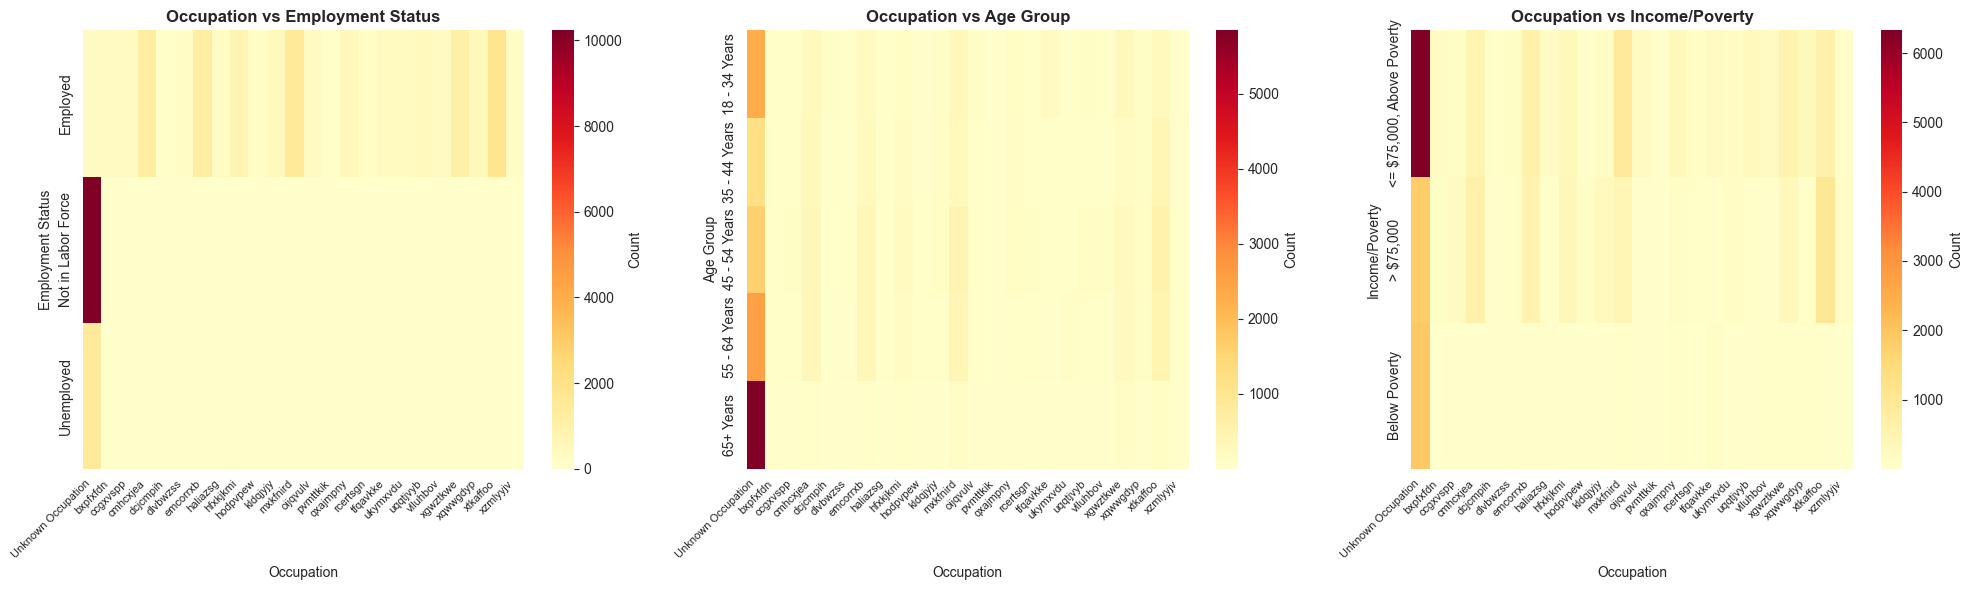


FINAL REPORT

MISSING VALUE FILLING COMPLETED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ All 0 missing values filled with "Unknown Occupation"

Data Quality:
  • Total Records: 26,707
  • Unique Occupations: 24
  • Missing Values: 0 (0.00%)
  • "Unknown Occupation" Records: 13,470

Next Steps:
  1. ✅ Use employment_occupation in analysis/modeling
  2. ✅ Consider "Unknown Occupation" as a valid category
  3. ⚠️ Document that Unknown values represent non-employed/retired populations
  4. 📊 Can now perform EDA on occupation variable
  5. 🔄 Can encode categorically for machine learning

Files Saved:
  • occupation_filled_distribution.png
  • occupation_filled_by_age.png
  • top_occupations.png
  • occupation_heatmap.png



In [ ]:

# ===== FILL MISSING VALUES WITH "UNKNOWN OCCUPATION" =====
print("="*80)
print("FILLING MISSING OCCUPATION DATA WITH 'UNKNOWN OCCUPATION'")
print("="*80)

# Check missing values before
print("\nBEFORE:")
print(f"Missing employment_occupation: {merged_df['employment_occupation'].isnull().sum()}")
print(f"Missing %: {merged_df['employment_occupation'].isnull().sum() / len(merged_df) * 100:.2f}%")

# Fill missing values
merged_df['employment_occupation'] = merged_df['employment_occupation'].fillna('Unknown Occupation')

# Check missing values after
print("\nAFTER:")
print(f"Missing employment_occupation: {merged_df['employment_occupation'].isnull().sum()}")
print(f"Missing %: {merged_df['employment_occupation'].isnull().sum() / len(merged_df) * 100:.2f}%")

# ===== SHOW VALUE COUNTS =====
print("\n" + "="*80)
print("OCCUPATION VALUE COUNTS (INCLUDING UNKNOWN)")
print("="*80)

occupation_counts = merged_df['employment_occupation'].value_counts(dropna=False)
print("\n" + occupation_counts.to_string())

# ===== DISTRIBUTION BY EMPLOYMENT STATUS =====
print("\n" + "="*80)
print("OCCUPATION DISTRIBUTION BY EMPLOYMENT STATUS")
print("="*80)

crosstab = pd.crosstab(
    merged_df['employment_status'], 
    merged_df['employment_occupation'],
    margins=True
)
print("\n" + crosstab.to_string())

# ===== DISTRIBUTION BY AGE GROUP =====
print("\n" + "="*80)
print("OCCUPATION DISTRIBUTION BY AGE GROUP")
print("="*80)

crosstab_age = pd.crosstab(
    merged_df['age_group'], 
    merged_df['employment_occupation'],
    margins=True
)
print("\n" + crosstab_age.to_string())

# ===== VISUALIZATION: OCCUPATION BY EMPLOYMENT STATUS =====
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS...")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Count of Occupation by Employment Status
occupation_by_emp = pd.crosstab(merged_df['employment_status'], merged_df['employment_occupation'])
occupation_by_emp.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Employment Occupation by Employment Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Employment Status', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Percentage Distribution
occupation_by_emp_pct = pd.crosstab(merged_df['employment_status'], merged_df['employment_occupation'], normalize='index') * 100
occupation_by_emp_pct.plot(kind='bar', ax=axes[1], stacked=True, edgecolor='black')
axes[1].set_title('Employment Occupation Distribution by Employment Status (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Employment Status', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('occupation_filled_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'occupation_filled_distribution.png'")
plt.show()

# ===== VISUALIZATION: OCCUPATION BY AGE GROUP =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Count of Occupation by Age Group
occupation_by_age = pd.crosstab(merged_df['age_group'], merged_df['employment_occupation'])
occupation_by_age.plot(kind='bar', ax=axes[0], edgecolor='black', stacked=False)
axes[0].set_title('Employment Occupation by Age Group', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Percentage Distribution
occupation_by_age_pct = pd.crosstab(merged_df['age_group'], merged_df['employment_occupation'], normalize='index') * 100
occupation_by_age_pct.plot(kind='bar', ax=axes[1], stacked=True, edgecolor='black')
axes[1].set_title('Employment Occupation Distribution by Age Group (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].legend(title='Occupation', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim([0, 100])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('occupation_filled_by_age.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'occupation_filled_by_age.png'")
plt.show()

# ===== VISUALIZATION: TOP OCCUPATIONS =====
fig, ax = plt.subplots(figsize=(12, 8))

top_occupations = merged_df['employment_occupation'].value_counts().head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_occupations)))
top_occupations.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Top 15 Employment Occupations (After Filling Missing)', fontsize=14, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Occupation', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')

# Add count labels
for i, v in enumerate(top_occupations.values):
    ax.text(v + 50, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_occupations.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'top_occupations.png'")
plt.show()

# ===== SUMMARY STATISTICS =====
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"""
Total Records: {len(merged_df):,}
Unique Occupations: {merged_df['employment_occupation'].nunique()}

Occupation Counts:
""")

# Get top 10 occupations
top_10 = merged_df['employment_occupation'].value_counts().head(10)
for idx, (occupation, count) in enumerate(top_10.items(), 1):
    pct = (count / len(merged_df)) * 100
    print(f"  {idx:2d}. {occupation:50s} : {count:6,} ({pct:5.2f}%)")

print(f"\n  ... and {merged_df['employment_occupation'].nunique() - 10} other occupations")

# ===== VERIFY NO MISSING VALUES =====
print("\n" + "="*80)
print("VERIFICATION")
print("="*80)

missing_check = merged_df['employment_occupation'].isnull().sum()
if missing_check == 0:
    print("\n✅ SUCCESS! No missing values in employment_occupation")
else:
    print(f"\n❌ WARNING! Still {missing_check} missing values")

# ===== HEATMAP: OCCUPATION BY KEY VARIABLES =====
print("\n" + "="*80)
print("CREATING HEATMAP...")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# By Employment Status
crosstab_emp = pd.crosstab(merged_df['employment_status'], merged_df['employment_occupation'])
sns.heatmap(crosstab_emp, annot=False, cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Occupation vs Employment Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Occupation', fontsize=10)
axes[0].set_ylabel('Employment Status', fontsize=10)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# By Age Group
crosstab_age = pd.crosstab(merged_df['age_group'], merged_df['employment_occupation'])
sns.heatmap(crosstab_age, annot=False, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Occupation vs Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Occupation', fontsize=10)
axes[1].set_ylabel('Age Group', fontsize=10)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

# By Income Poverty
crosstab_income = pd.crosstab(merged_df['income_poverty'], merged_df['employment_occupation'])
sns.heatmap(crosstab_income, annot=False, cmap='YlOrRd', ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title('Occupation vs Income/Poverty', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Occupation', fontsize=10)
axes[2].set_ylabel('Income/Poverty', fontsize=10)
plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('occupation_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Chart saved as 'occupation_heatmap.png'")
plt.show()

# ===== FINAL REPORT =====
print("\n" + "="*80)
print("FINAL REPORT")
print("="*80)

print(f"""
MISSING VALUE FILLING COMPLETED:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✅ All {merged_df['employment_occupation'].isnull().sum()} missing values filled with "Unknown Occupation"

Data Quality:
  • Total Records: {len(merged_df):,}
  • Unique Occupations: {merged_df['employment_occupation'].nunique()}
  • Missing Values: {merged_df['employment_occupation'].isnull().sum()} (0.00%)
  • "Unknown Occupation" Records: {(merged_df['employment_occupation'] == 'Unknown Occupation').sum():,}

Next Steps:
  1. ✅ Use employment_occupation in analysis/modeling
  2. ✅ Consider "Unknown Occupation" as a valid category
  3. ⚠️ Document that Unknown values represent non-employed/retired populations
  4. 📊 Can now perform EDA on occupation variable
  5. 🔄 Can encode categorically for machine learning

Files Saved:
  • occupation_filled_distribution.png
  • occupation_filled_by_age.png
  • top_occupations.png
  • occupation_heatmap.png
""")

print("=" * 80)